<a href="https://colab.research.google.com/github/magerandy/Commercial-Performance-Analysis/blob/main/Portfolio_Project_1_MAGERA_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Installing and Importing Required Libraries / Встановлення та імпорт необхідних бібліотек

In [ ]:
!pip install --upgrade google-cloud-bigquery

from google.colab import auth
from google.cloud import bigquery

import pandas as pd
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

### User Authentication in Google Colab / Аутентифікація користувача в Google Colab

In [ ]:
auth.authenticate_user()

### Initializing BigQuery Client / Ініціалізація клієнта BigQuery

In [ ]:
client = bigquery.Client(project="data-analytics-mate")

### Writing SQL Query for Data Extraction / Написання SQL-запиту для вивантаження даних

In [ ]:
# sql query
sql = """
SELECT
  s.date,
  s.ga_session_id,
  a.id AS account_id,
  a.is_verified,
  a.is_unsubscribed,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,
  sp.medium AS traffic_type,
  sp.channel AS traffic_channel,
  sp.name AS traffic_source_name,
  p.category,
  p.name AS product_name,
  p.price,
  p.short_description,
FROM data-analytics-mate.DA.session AS s
LEFT JOIN data-analytics-mate.DA.session_params AS sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN data-analytics-mate.DA.order AS o
  ON o.ga_session_id = s.ga_session_id
LEFT JOIN data-analytics-mate.DA.product AS p
  ON p.item_id = o.item_id
LEFT JOIN data-analytics-mate.DA.account_session AS acs
  ON acs.ga_session_id = s.ga_session_id
LEFT JOIN data-analytics-mate.DA.account AS a
  ON a.id = acs.account_id
"""

### Executing SQL Query and Loading Data into DataFrame / Виконання SQL-запиту та завантаження даних у DataFrame

In [ ]:
query = client.query(sql)
df = query.to_dataframe(create_bqstorage_client=False)

# **EXPLORARY DATA ANALYSIS**

### Displaying the First Rows of the DataFrame / Відображення перших рядків DataFrame

In [ ]:
df.head()

,date,ga_session_id,account_id,is_verified,is_unsubscribed,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_type,traffic_channel,traffic_source_name,category,product_name,price,short_description
0,2020-11-01,967742695,<NA>,<NA>,<NA>,Americas,United States,desktop,Safari,Safari,Web,en-us,(data deleted),Undefined,(data deleted),Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,9065007548,<NA>,<NA>,<NA>,Asia,China,desktop,Chrome,Safari,Web,None,(data deleted),Undefined,(data deleted),Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3267062634,<NA>,<NA>,<NA>,Americas,United States,desktop,Chrome,Safari,Web,en-us,(data deleted),Undefined,(data deleted),Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
3,2020-11-01,8892952409,<NA>,<NA>,<NA>,Americas,United States,mobile,Android Webview,<Other>,Web,ko,(data deleted),Undefined,(data deleted),None,None,NaN,None
4,2020-11-01,1624570787,<NA>,<NA>,<NA>,Asia,Turkey,desktop,<Other>,<Other>,Web,en-us,(data deleted),Undefined,(data deleted),None,None,NaN,None


### Inspecting Data Types and Structure / Перевірка типів даних та структури

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 349545 non-null  dbdate 
 1   ga_session_id        349545 non-null  Int64  
 2   account_id           27945 non-null   Int64  
 3   is_verified          27945 non-null   Int64  
 4   is_unsubscribed      27945 non-null   Int64  
 5   continent            349545 non-null  object 
 6   country              349545 non-null  object 
 7   device               349545 non-null  object 
 8   browser              349545 non-null  object 
 9   mobile_model_name    349545 non-null  object 
 10  operating_system     349545 non-null  object 
 11  language             235279 non-null  object 
 12  traffic_type         349545 non-null  object 
 13  traffic_channel      349545 non-null  object 
 14  traffic_source_name  349545 non-null  object 
 15  category         

### Calculating the Percentage of Missing Values per Column / Розрахунок відсотка пропущених значень для кожної колонки

In [ ]:
df.isna().mean() * 100

,0
date,0.000000
ga_session_id,0.000000
account_id,92.005321
is_verified,92.005321
is_unsubscribed,92.005321
continent,0.000000
country,0.000000
device,0.000000
browser,0.000000
mobile_model_name,0.000000


### Summary of Unique Sessions and Date Range / Підсумок унікальних сесій та часового діапазону

In [ ]:
print(df["ga_session_id"].nunique())
print(df["date"].min(), df["date"].max())

349545
2020-11-01 2021-01-31


### Summary of Dataset Metrics & Missing Values Analysis / Підсумок метрик датасету та аналіз пропущених значень

* **Total number of columns / Загальна кількість колонок:** 19
* **Number of numerical columns / Кількість числових колонок:** 6  
  (`ga_session_id`, `account_id`, `is_verified`, `is_unsubscribed`, `price`, `date`)
* **Number of categorical columns / Кількість категоріальних колонок:** 13  
  (`continent`, `country`, `device`, `browser`, `mobile_model_name`, `operating_system`, `language`, `traffic_type`, `traffic_channel`, `traffic_source_name`, `product_name`, `category`, `short_description`)
* **Number of datetime columns / Кількість колонок типу datetime:** 0
* **Number of unique sessions / Кількість унікальних сесій:** 349,545
* **Time period under review / Розглянутий період:** 2020-11-01 — 2021-01-31

* **Are there any missing values? / Чи є пропущені значення?:** Yes, there are / Так, є.
* **Which columns have the most missing values and why? / У яких колонках найбільше пропусків та чому?:**  

  >  The highest number of missing values is observed in the `category`, `product_name`, `price`, `short_description`, `account_id`, `is_verified`, and `is_unsubscribed` columns. This is because most sessions on the site do not result in a purchase, and most users do not register, so these fields remain empty for such sessions.  
  ---
  >  Найбільша кількість пропущених значень спостерігається в колонках `category`, `product_name`, `price`, `short_description`, `account_id`, `is_verified` та `is_unsubscribed`. Це пов'язано з тим, що більшість сесій на сайті не завершуються покупкою, а більшість користувачів не реєструються, тому для таких сесій ці поля залишаються порожніми.

  ---

# **DATA CLEANING & PREPROCESSING / ОЧИЩЕННЯ ТА ПЕРЕДОБРОБКА ДАНИХ**

### Data Quality Notes & Missing Values Explanation / Примітки щодо якості даних та пояснення пропусків

* **`account_id` (27,945 non-null):** Remaining sessions belong to guest/unregistered users. / Решта сесій належать незареєстрованим користувачам.
* **`price` (33,538 non-null):** Remaining sessions represent visits without completed orders. / Решта сесій є візитами без оформлених замовлень.

### Converting Date Column to Datetime Format / Перетворення колонки з датою у формат Datetime


In [ ]:
df["date"] = pd.to_datetime(df["date"])

### Trimming Whitespace from Text Columns / Видалення пробілів у текстових колонках


In [ ]:
strip_columns = df.select_dtypes(include=["object"]).columns
for col in strip_columns:
    df[col] = df[col].str.strip()

### Handling Missing Values in Categorical and Numerical Columns / Обробка пропущених значень у категоріальних та числових колонках


In [ ]:
df[["category", "product_name", "language"]] = df[["category", "product_name", "language"]].fillna("unknown")
df[["account_id", "is_verified", "is_unsubscribed", "price"]] = df[["account_id", "is_verified", "is_unsubscribed", "price"]].fillna(0)
df["short_description"] = df["short_description"].fillna("None")

### Session Frequency Analysis & Duplicate Checking / Аналіз частоти сесій та перевірка на дублікати

In [ ]:
df.duplicated().sum()

np.int64(0)

### Summary Statistics & Anomaly Detection Across Numerical Features / Зведена статистика та пошук аномалій у числових ознаках

In [ ]:
df.describe()

,date,ga_session_id,account_id,is_verified,is_unsubscribed,price
count,349545,349545.0,349545.0,349545.0,349545.0,349545.000000
mean,2020-12-16 12:42:00.602497536,4992250296.631739,52685.338245,0.05732,0.013546,91.466710
min,2020-11-01 00:00:00,1205.0,0.0,0.0,0.0,0.000000
25%,2020-11-26 00:00:00,2493646855.0,0.0,0.0,0.0,0.000000
50%,2020-12-15 00:00:00,4988476074.0,0.0,0.0,0.0,0.000000
75%,2021-01-08 00:00:00,7491286508.0,0.0,0.0,0.0,0.000000
max,2021-01-31 00:00:00,9999997129.0,681962.0,1.0,1.0,9585.000000
std,NaN,2887450949.537772,178768.609336,0.232454,0.115597,495.222334


### Overview of Dataset Structure, Data Types, and Missing Values / Загальний огляд структури датасету, типів даних та пропусків

In [ ]:
df.describe()

,date,ga_session_id,account_id,is_verified,is_unsubscribed,price
count,349545,349545.0,349545.0,349545.0,349545.0,349545.000000
mean,2020-12-16 12:42:00.602497536,4992250296.631739,52685.338245,0.05732,0.013546,91.466710
min,2020-11-01 00:00:00,1205.0,0.0,0.0,0.0,0.000000
25%,2020-11-26 00:00:00,2493646855.0,0.0,0.0,0.0,0.000000
50%,2020-12-15 00:00:00,4988476074.0,0.0,0.0,0.0,0.000000
75%,2021-01-08 00:00:00,7491286508.0,0.0,0.0,0.0,0.000000
max,2021-01-31 00:00:00,9999997129.0,681962.0,1.0,1.0,9585.000000
std,NaN,2887450949.537772,178768.609336,0.232454,0.115597,495.222334


### Summary Statistics and explore data for anomalies in sessions with purchases (price > 0) / Зведена статистика та дослідження даних про наявність аномалій у сесіях із покупками (price > 0)  

In [ ]:
df.query("price > 0").describe()

,date,ga_session_id,account_id,is_verified,is_unsubscribed,price
count,33538,33538.0,33538.0,33538.0,33538.0,33538.000000
mean,2020-12-14 15:09:05.506589184,4964900683.146312,54629.55382,0.059306,0.013328,953.298679
min,2020-11-01 00:00:00,330355.0,0.0,0.0,0.0,3.000000
25%,2020-11-25 00:00:00,2476893918.0,0.0,0.0,0.0,170.000000
50%,2020-12-13 00:00:00,4961245290.0,0.0,0.0,0.0,445.000000
75%,2021-01-06 00:00:00,7442296865.75,0.0,0.0,0.0,1195.000000
max,2021-01-27 00:00:00,9999754183.0,681955.0,1.0,1.0,9585.000000
std,NaN,2884281407.544152,181718.757991,0.2362,0.114677,1317.001775


### Summary of Dataset Architecture & Memory Usage / Підсумок архітектури датасету та використання пам'яті

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 349545 non-null  datetime64[ns]
 1   ga_session_id        349545 non-null  Int64         
 2   account_id           349545 non-null  Int64         
 3   is_verified          349545 non-null  Int64         
 4   is_unsubscribed      349545 non-null  Int64         
 5   continent            349545 non-null  object        
 6   country              349545 non-null  object        
 7   device               349545 non-null  object        
 8   browser              349545 non-null  object        
 9   mobile_model_name    349545 non-null  object        
 10  operating_system     349545 non-null  object        
 11  language             349545 non-null  object        
 12  traffic_type         349545 non-null  object        
 13  traffic_channe

---
###**Conclusion:**
>For a comprehensive understanding of the data, two statistical analyses were conducted in two views: one across the entire dataset to assess overall activity, and another separately for sessions with completed purchases (price > 0) for a detailed analysis of pricing policy.

>This allows us to avoid skewing average price metrics due to the absence of orders in the majority of sessions.



>In the filtered dataset, the mean price value (mean ≈ 953) significantly exceeds the median (50% = 445). This indicates the presence of right-side skewness and some large orders ("outliers") that inflate the mean value.
These data points are not necessarily technical errors, so we retain them in the analysis to reflect the actual sales landscape.

---
### **Висновок:**

>Для комплексного розуміння даних було проведено два статистичні аналізи у двох розрізах: один по всьому датасету для оцінки загальної активності, а інший — окремо для сесій із завершеними покупками (`price > 0`) для детального аналізу цінової політики.

>Це дозволяє уникнути викривлення показників середньої ціни через відсутність замовлень у більшості сесій.

>У відфільтрованому датасеті середнє значення ціни (**mean ≈ 953**) значно перевищує медіану (**50% = 445**). Це вказує на наявність правосторонньої асиметрії (правобічного скосу) та деяких великих замовлень («викидів»), які завищують середнє значення. Ці дані не обов'язково є технічними помилками, тому ми зберігаємо їх в аналізі, щоб відобразити реальну картину продажів.
---

## **Business Performance Analysis / Аналіз ефективності бізнесу**

### **1. Geographic Sales Performance & Regional Revenue Distribution / Географічні показники продажів та регіональний розподіл виручки**

### Calculate total revenue by continent, filtering for valid sales only / Розрахунок загального доходу за континентами, відфільтрувавши лише актуальні продажі

In [ ]:
top_continents_revenue = df.query("price > 0").groupby("continent")[["price"]].sum().sort_values(by="price", ascending = False).head(3).reset_index()
top_continents_revenue

,continent,price
0,Americas,17665280.0
1,Asia,7601298.3
2,Europe,5934624.2


### Top 3 Continents by Traffic Volume / ТОП-3 континенти за обсягом трафіку (сесій)

In [ ]:
top_continents_order = df.groupby("continent")[["ga_session_id"]].count().sort_values(by="ga_session_id", ascending = False).head(3).reset_index()
top_continents_order

,continent,ga_session_id
0,Americas,193179
1,Asia,83113
2,Europe,65135


### Top 5 Countries by Revenue / Топ-5 країн за доходом

In [ ]:
top_countries_revenue = df.query("price > 0").groupby("country")["price"].sum().sort_values(ascending = False).head().reset_index()
top_countries_revenue

,country,price
0,United States,13943553.9
1,India,2809762.0
2,Canada,2437921.0
3,United Kingdom,938317.9
4,France,710692.8


### Session Frequency by Country to Determine User Engagement / Розрахунок частоти сесій за країнами для визначення залученості користувачів

In [ ]:
top_countries_order = df.groupby("country")["ga_session_id"].count().sort_values(ascending = False).head().reset_index()
top_countries_order

,country,ga_session_id
0,United States,153470
1,India,32763
2,Canada,25994
3,United Kingdom,11003
4,France,6958


### Geographic Performance: Revenue vs. Order Volume by Continent / Географічні показники: порівняння доходу та обсягу замовлень за континентами

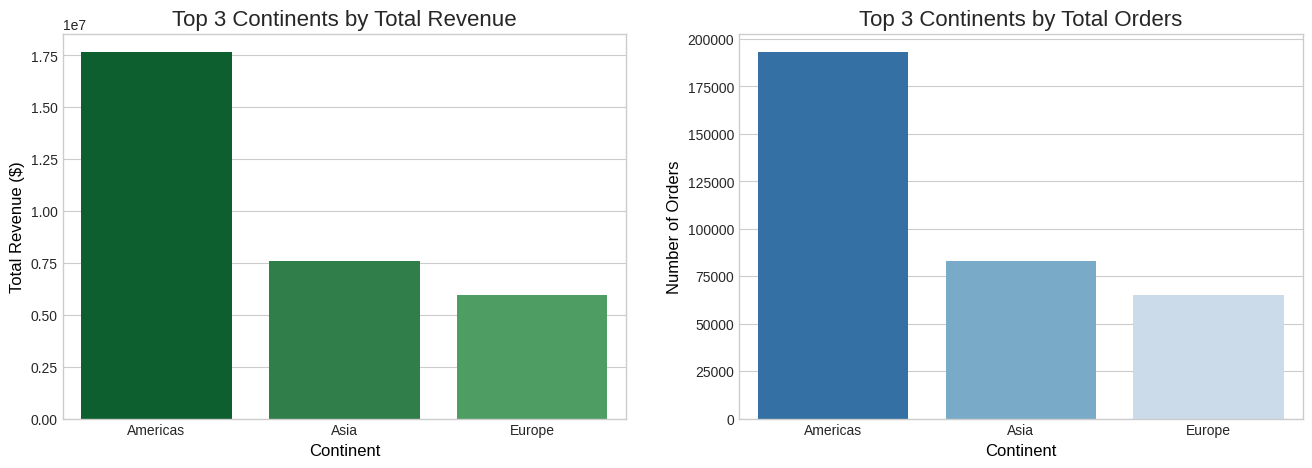

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=top_continents_revenue, x="continent", y="price", palette=["#006d2c", "#238b45", "#41ab5d"], hue="continent", legend=False, width=0.8, ax=axes[0])
axes[0].set_title("Top 3 Continents by Total Revenue", fontsize=16)
axes[0].set_xlabel("Continent", color = "black", fontsize=12)
axes[0].set_ylabel("Total Revenue ($)", color = "black", fontsize=12)

sns.barplot(data=top_continents_order, x="continent", y="ga_session_id", palette="Blues_r", hue="continent", legend=False, width=0.8, ax=axes[1])
axes[1].set_title("Top 3 Continents by Total Orders", fontsize=16)
axes[1].set_xlabel("Continent", color = "black", fontsize=12)
axes[1].set_ylabel("Number of Orders", color = "black", fontsize=12)

plt.show()

### Visualizing Top 5 Countries by Revenue and Order Volume / Візуалізація ТОП-5 країн за доходом та кількістю замовлень


/tmp/ipykernel_3513/4195300592.py:7: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=top_countries_revenue, x="country", y="price", palette=["#006d2c", "#238b45", "#41ab5d"], hue="country", legend=False, width=0.8, ax=axes[0])


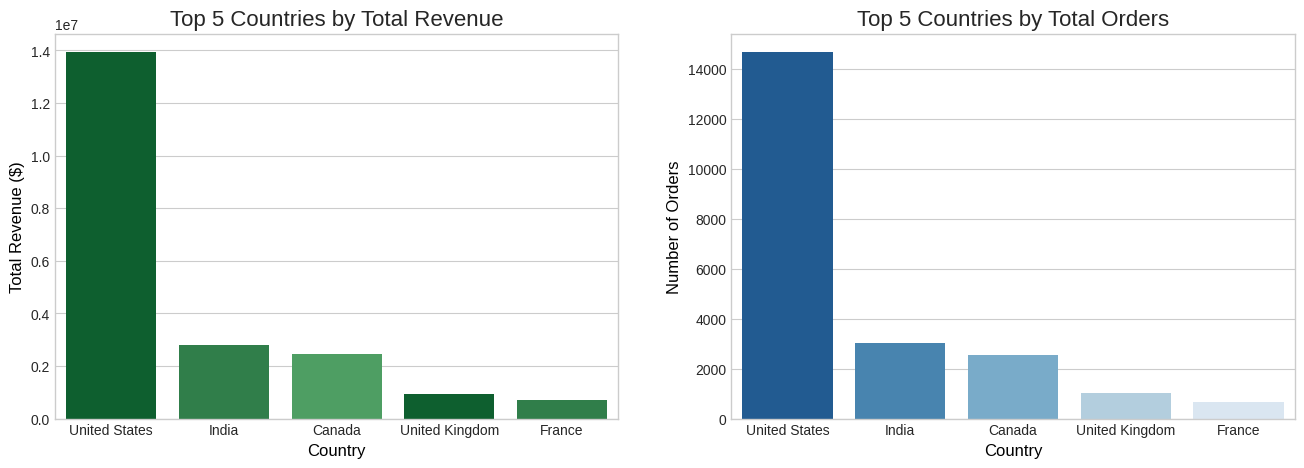

In [ ]:
top_countries_revenue = df.query("price > 0").groupby("country")[["price"]].sum().sort_values(by="price", ascending=False).head(5).reset_index()
top_countries_order = df.query("price > 0").groupby("country")["ga_session_id"].count().sort_values(ascending=False).head(5).reset_index()

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=top_countries_revenue, x="country", y="price", palette=["#006d2c", "#238b45", "#41ab5d"], hue="country", legend=False, width=0.8, ax=axes[0])
axes[0].set_title("Top 5 Countries by Total Revenue", fontsize=16)
axes[0].set_xlabel("Country", color="black", fontsize=12)
axes[0].set_ylabel("Total Revenue ($)", color="black", fontsize=12)

sns.barplot(data=top_countries_order, x="country", y="ga_session_id", palette="Blues_r", hue="country", legend=False, width=0.8, ax=axes[1])
axes[1].set_title("Top 5 Countries by Total Orders", fontsize=16)
axes[1].set_xlabel("Country", color="black", fontsize=12)
axes[1].set_ylabel("Number of Orders", color="black", fontsize=12)

plt.show()

---
### **Conclusion**

> **Dominance of the Americas:** The Americas region leads by a wide margin in total revenue and order volume, substantially ahead of both Asia and Europe.
> **US Market Leadership:** On a country level, the United States serves as the main engine of growth, capturing the highest revenue and order totals among the top five markets.
> **Revenue-Order Alignment:** Order volume aligns closely with total revenue across geographic regions, demonstrating strong conversion of market traffic into monetized sales.
> **Market Opportunity:** Despite US market dominance, the performance gap relative to countries like India and Canada highlights heavy revenue concentration—presenting a clear opportunity to expand targeted marketing and balance regional exposure.

---

### **Висновки**

> **Домінування регіону Americas:** Північна та Південна Америка є абсолютними лідерами за загальним доходом і кількістю замовлень, випереджаючи Азію та Європу.
> **Лідерство ринку США:** У глобальному розрізі США виступають головним рушієм бізнесу, отримуючи наибольший дохід та обсяг замовлень серед ТОП-5 країн.
> **Взаємозв'язок доходу та замовлень:** Обсяг замовлень чітко корелює з отриманим доходом у всіх регіонах і країнах, що свідчить про ефективну конверсію трафіку в реальні продажі.
> **Можливості для розвитку:** Попри домінування США, значний розрив із такими країнами, як Індія та Канада, вказує на високу концентрацію клієнтської бази. Це відкриває можливості для таргетованого маркетингу з метою диверсифікації регіональних ризиків.
---

## **2. Top 10 Product Categories Analysis / Аналіз ТОП-10 категорій товарів**

### Total Revenue by Top 10 Product Categories / Загальний доход за топ-10 категоріями товарів

In [ ]:
top_categories_revenue = df.query("price > 0").groupby("category")[["price"]].sum().sort_values(by="price", ascending=False).head(10).reset_index()
top_categories_revenue

,category,price
0,Sofas & armchairs,8388254.5
1,Chairs,6147748.8
2,Beds,4919725.0
3,Bookcases & shelving units,3640818.1
4,Cabinets & cupboards,2336499.5
5,Outdoor furniture,2142222.2
6,Tables & desks,1790307.5
7,Chests of drawers & drawer units,906562.5
8,Bar furniture,735503.0
9,Children's furniture,467697.0


### Visualizing Top 10 Product Categories by Total Revenue / Візуалізація ТОП-10 категорій товарів за загальним доходом

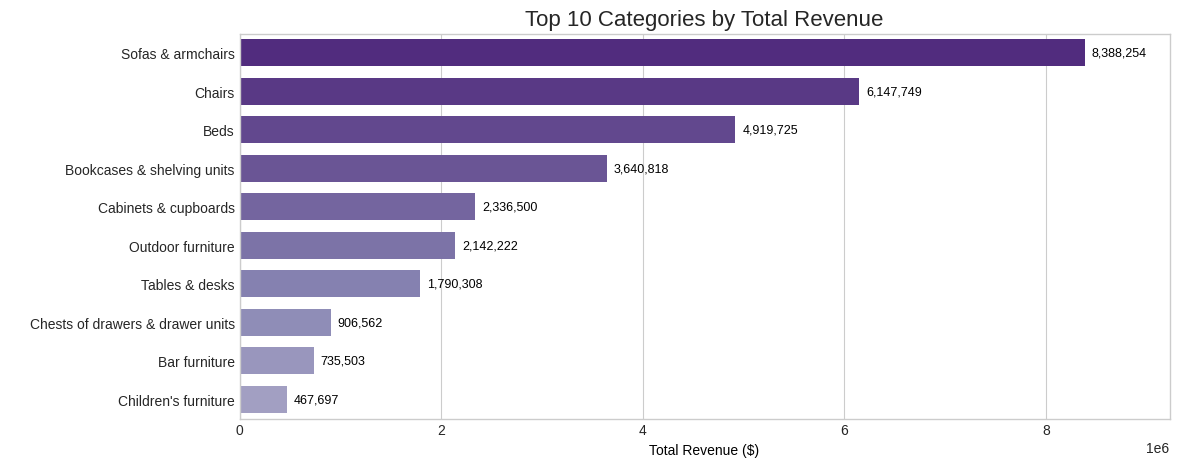

In [ ]:
plt.figure(figsize=(12, 5))

colors_gradient = plt.cm.Purples(np.linspace(0.9, 0.5, 10)).tolist()

ax = sns.barplot(data=top_categories_revenue, x="price", y="category", palette=colors_gradient, hue="category", legend=False, width=0.7)
plt.title("Top 10 Categories by Total Revenue", fontsize=16)
plt.xlabel("Total Revenue ($)", color="black")
plt.ylabel(" ", color="black")
ax.set_xlim(right=top_categories_revenue["price"].max() * 1.1)
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=5, fontsize=9, color="black")

plt.show()

---
### **Conclusion**

> **Revenue Concentration:** The majority of total sales is heavily concentrated in the top three product categories—"Sofas & armchairs," "Chairs," and "Beds"—making core furniture essentials the primary drivers of overall performance.
> **Portfolio Disparity:** High-performing categories generate the bulk of income, whereas lower-ranking segments like "Children's furniture" yield minimal returns.
> **Strategic Optimization:** The significant gap between top and bottom categories highlights an opportunity to optimize the product portfolio and reallocate marketing efforts toward higher-potential lines.

---

### **Висновки**

> **Концентрація доходу:** Основна частка продажів зосереджена у трьох ключових категоріях — «Дивани та крісла», «Стільці» та «Ліжка», які є головними рушіями загального виторгу.
> **Диспропорція портфеля:** Поки базові категорії меблів забезпечують левову частку прибутку, нижні позиції списку, такі як «Дитячі меблі», генерують мінімальний дохід.
> **Оптимізація стратегії:** Значний розрив між лідерами та аутсайдерами вказує на доцільність перегляду товарного асортименту та перерозподілу маркетингового бюджету на користь більш прибуткових напрямків.
---

## **3. Browser Performance Analysis / Аналіз ефективності браузерів**

### Average Revenue per Session by Browser / Середній дохід на сесію за браузерами


In [ ]:
browser_avg_price = df.groupby("browser")["price"].mean().sort_values(ascending=False).reset_index()
browser_avg_price

,browser,price
0,<Other>,103.399194
1,Android Webview,92.466682
2,Chrome,91.532542
3,Safari,90.404593
4,Edge,89.298803
5,Firefox,88.220675


### Visualizing Average Revenue per Session by Browser / Візуалізація середнього доходу на сесію за браузерами

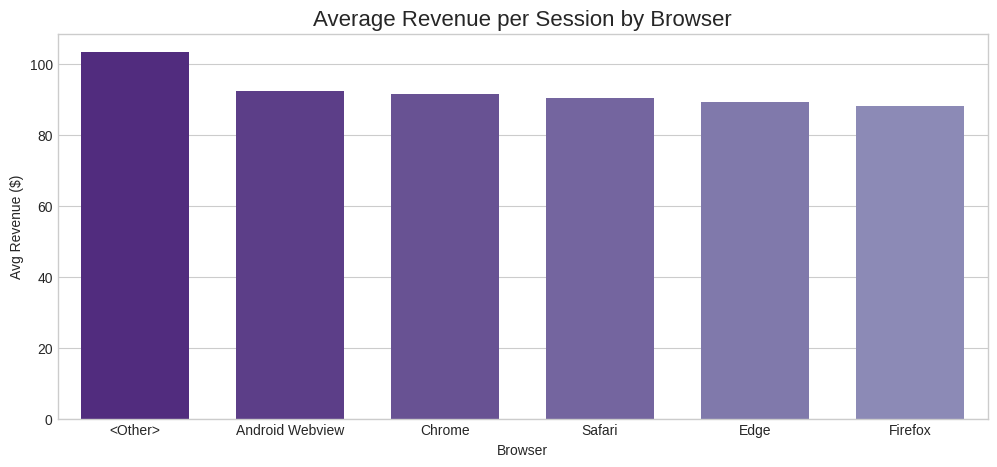

In [ ]:
plt.figure(figsize=(12, 5))
colors_gradient = plt.cm.Purples(np.linspace(0.9, 0.6, 6)).tolist()

ax = sns.barplot(data=browser_avg_price, x="browser", y="price", palette=colors_gradient, hue="browser", width=0.7)
plt.title("Average Revenue per Session by Browser", fontsize=16)
plt.ylabel("Avg Revenue ($)")
plt.xlabel("Browser")

plt.show()

---
### **Conclusion**

> **Consistent Performance:** Average revenue per session remains highly consistent across all major web browsers, staying strictly within the 88 to 92 range.
> **Cross-Browser Stability:** Uniform revenue metrics indicate that user experience is equally balanced and effective regardless of the user's browser choice.
> **Technical Integrity:** The platform operates seamlessly across different web environments without technical biases, friction, or conversion barriers.

---

### **Висновки**

> **Стабільність показників:** Середній дохід на сесію залишається максимально рівномірним для всіх основних браузерів і чітко утримується в межах 88–92.
> **Рівноцінність користувацького досвіду:** Однакова ефективність монетизації свідчить про те, що якість взаємодії з платформою є однаково високою незалежно від обраного вебпереглядача.
> **Відсутність технічних бар'єрів:** Платформа працює без збоїв у різних вебсередовищах, не створюючи додаткових перешкод для конверсії користувачів.
---

## **4. Traffic Source Performance Analysis / Аналіз ефективності джерел трафіку**

### Total Sales Revenue by Traffic Channel / Загальний дохід за каналами трафіку

In [ ]:
traffic_source = df.groupby("traffic_channel")["price"].sum()
traffic_source

,price
traffic_channel,
Direct,7494923.4
Organic Search,11433151.6
Paid Search,8511049.4
Social Search,2532105.7
Undefined,2000501.0


### Traffic Channel Revenue Share Percentage / Частка доходу за каналами трафіку (%)

In [ ]:
traffic_pct = (traffic_source / traffic_source.sum()) * 100
traffic_pct = traffic_pct.sort_values(ascending=False)
traffic_pct.round(2)

,price
traffic_channel,
Organic Search,35.76
Paid Search,26.62
Direct,23.44
Social Search,7.92
Undefined,6.26


### Visualizing Sales Share by Traffic Channel / Візуалізація частки продажів за каналами трафіку

In [ ]:
fig = px.pie(
    traffic_pct.reset_index(),
    values="price",
    names="traffic_channel",
    hole=0.6,
    color_discrete_sequence=px.colors.sequential.Purples_r
)

fig.update_traces(
    pull=[0.01] * len(traffic_pct),
    textinfo="label+percent",
    textposition="outside",
    direction="clockwise",
    sort=False,
    textfont=dict(size=14, family="Arial, sans-serif", color="#2D2D2D", weight="bold"),
    marker=dict(line=dict(color="#FFFFFF", width=2)),
    hoverinfo="label+value+percent",
    hovertemplate="<b>%{label}</b><br>Revenue: $%{value:,.2f}<br>Share: %{percent}<extra></extra>"
)

fig.update_layout(
    title_text="Sales Share by Traffic Channel (%)",
    title_x=0.5,
    title_font=dict(size=22, family="Arial, sans-serif", color="#2D2D2D"),
    showlegend=False,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(t=80, b=50, l=50, r=50)
)

fig.show()

---
### **Conclusion**

> **Core Revenue Drivers:** Organic Search serves as the primary revenue channel, generating 35.8% of total sales, followed by Paid Search (26.6%) and Direct traffic (23.4%).
> **Channel Dominance:** Together, the top three channels drive the vast majority of performance, accounting for 85.8% of overall revenue.
> **Secondary Sources:** Social Search (7.92%) and Undefined sources (6.26%) play a secondary role, representing only a minor fraction of overall sales.

---

### **Висновки**

> **Ключові джерела доходу:** Органічний пошук (Organic Search) є головним драйвером продажів, забезпечуючи 35.8% загального виторгу, за ним йдуть платний пошук (26.6%) та прямі заходи (23.4%).
> **Домінування топканалів:** Разом ці три ключові джерела формують левову частку результату — 85.8% від усього доходу.
> **Вторинні канали:** Соціальні мережі (7.92%) та невизначені джерела (6.26%) відіграють другорядну роль, складаючи незначну частину підсумкових продажів.
---

# **Sales Dynamics Analysis / Аналіз динаміки продажів**

## **1. Overall Sales Trends: Daily Revenue / Загальні тенденції продажів: щоденний доход**

In [ ]:
daily_revenue = df.query("price > 0").groupby("date")["price"].sum().reset_index()

### Visualizing General Sales Dynamics / Візуалізація загальної динаміки продажів

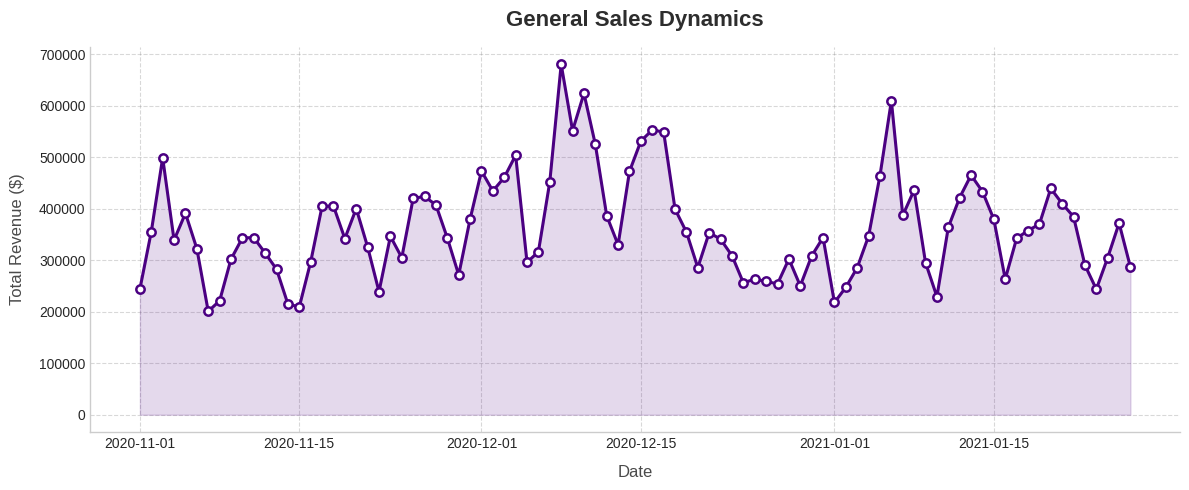

In [ ]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=daily_revenue,
    x="date",
    y="price",
    color="#4B0082",
    linewidth=2.2,
    marker="o",
    markersize=6,
    markerfacecolor="#FFFFFF",
    markeredgecolor="#4B0082",
    markeredgewidth=1.8
)

plt.fill_between(
    daily_revenue["date"],
    daily_revenue["price"],
    color="#4B0082",
    alpha=0.15
)

plt.title("General Sales Dynamics", fontsize=16, fontweight="bold", pad=15, color="#2D2D2D")
plt.xlabel("Date", fontsize=12, labelpad=10, color="#4A4A4A")
plt.ylabel("Total Revenue ($)", fontsize=12, labelpad=10, color="#4A4A4A")

plt.grid(True, linestyle="--", alpha=0.3, color="gray")
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

---
### **Conclusion**

> **Seasonal Volatility:** The data reveals noticeable cyclical fluctuations, with prominent peaks in mid-December and early January, driven by seasonal demand or promotional campaigns.
> **Stable Core Revenue:** Despite daily variations, revenue consistently holds above a $200,000 baseline, demonstrating steady underlying demand.
> **Business Resilience:** The combination of peak-period spikes and a strong baseline confirms both high campaign effectiveness and solid operational stability throughout the analyzed timeframe.

---

### **Висновки**

> **Сезонна циклічність:** Дані демонструють виражену циклічну коливальність із чіткими піками у середині грудня та на початку січня, що свідчить про вплив сезонного попиту чи промо-активностей.
> **Стабільний базовий дохід:** Попри щоденні коливання, дохід утримується вище базової позначки у $200,000, підтверджуючи стійкий фундаментальний попит.
> **Стійкість показників:** Поєднання періодичних сплесків із високим базовим рівнем свідчить про ефективність маркетингових кампаній та надійну операційну стабільність упродовж усього досліджуваного періоду.
---

## **2. Weekly Seasonality Analysis / Аналіз тижневої сезонності**

### Day of Week Column Creation / Створення стовпця "день тижня" на основі дати

In [ ]:
df["day_of_week"] = df["date"].dt.day_name()

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly_seasonality = df.query("price > 0").groupby("day_of_week")["price"].mean().reindex(days_order).reset_index()

weekly_seasonality

,day_of_week,price
0,Monday,934.359210
1,Tuesday,946.992174
2,Wednesday,973.734040
3,Thursday,984.433819
4,Friday,986.277191
5,Saturday,933.939554
6,Sunday,896.589623


### Visualizing Weekly Seasonality / Візуалізація тижневої сезонності

/tmp/ipykernel_3513/1803677710.py:3: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#76448A'` for the same effect.




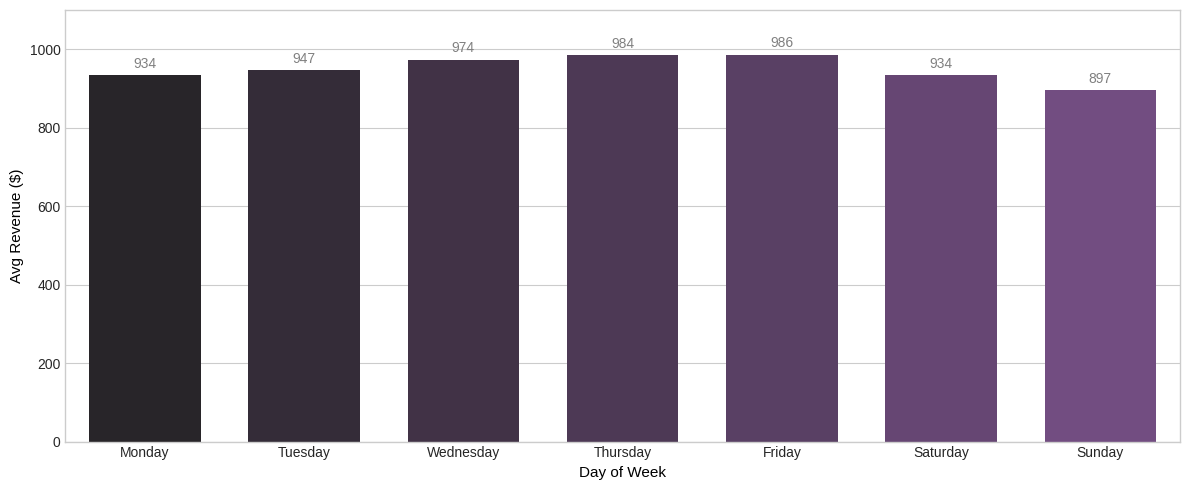

In [ ]:
plt.figure(figsize=(12, 5))

ax = sns.barplot(
    data=weekly_seasonality,
    x="day_of_week",
    y="price",
    color="#76448A",
    hue="day_of_week",
    legend=False,
    width=0.7
)

plt.xlabel("Day of Week", color="black", fontsize=11)
plt.ylabel("Avg Revenue ($)", color="black", fontsize=11)
ax.set_ylim(0, 1100)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3, fontsize=10, color="gray")

plt.tight_layout()
plt.show()

---
### **Conclusion**

> **Midweek Peak:** Revenue remains relatively steady through the workweek, building toward a peak from Wednesday through Friday, when it reaches its maximum (986).
> **Weekend Dip:** Purchasing activity drops noticeably over the weekend, touching its lowest point on Sunday (897).
> **Workday Purchasing Behavior:** The higher sales volume during weekdays indicates that users are far more inclined to make purchases during working hours.

---

### **Висновки**

> **Сплеск у середині тижня:** Дохід залишається відносно стабільним протягом робочих днів із поступовим зростанням від середи до п'ятниці, коли він досягає максимуму (986).
> **Вихідний спад:** Покупецька активність помітно знижується у вихідні дні, досягаючи мінімуму в неділю (897).
> **Поведінка в робочі дні:** Вищий рівень продажів у будні свідчить про те, що користувачі схильні здійснювати покупки переважно під час робочого тижня.
---

## **3. Comparative Analysis of Sales Dynamics: Americas, Asia, and Europe / Порівняльний аналіз динаміки продажів: Америка, Азія та Європа**

### Weekly Sales Revenue by Continent / Тижневий доход від продажів за континентами

In [ ]:
dynamics_by_continent = df.query("price > 0 and continent in ['Americas', 'Asia', 'Europe']").set_index("date").groupby("continent")["price"].resample("W").sum().reset_index()
dynamics_by_continent

,continent,date,price
0,Americas,2020-11-01,132002.5
1,Americas,2020-11-08,1249284.6
2,Americas,2020-11-15,1045330.9
3,Americas,2020-11-22,1353865.0
4,Americas,2020-11-29,1433004.3
5,Americas,2020-12-06,1600256.8
6,Americas,2020-12-13,1946409.7
7,Americas,2020-12-20,1735085.9
8,Americas,2020-12-27,1170444.7
9,Americas,2021-01-03,1013053.8


### Visualizing Weekly Revenue Trends by Continent / Візуалізація тижневих трендів доходу за континентами

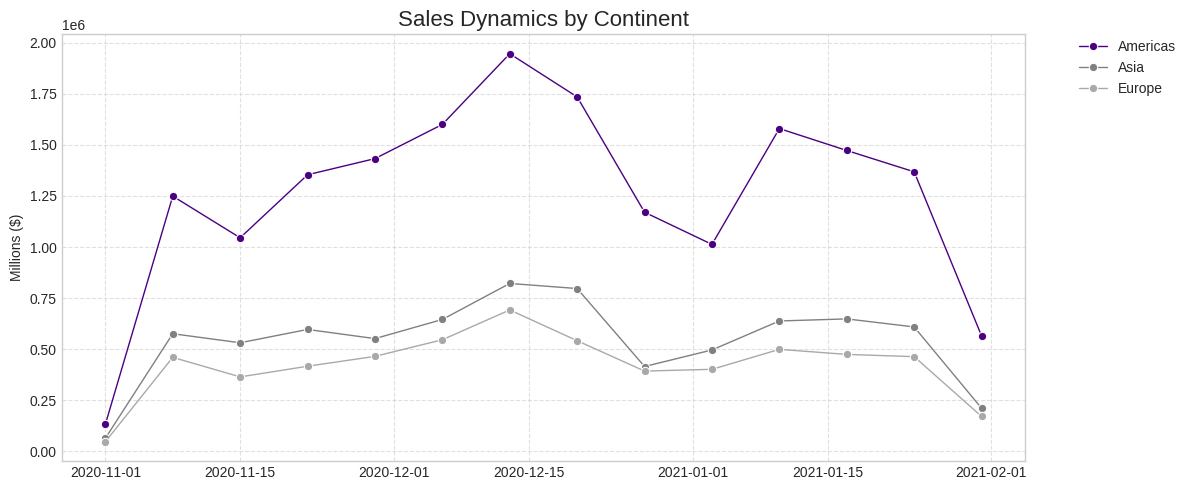

In [ ]:
plt.figure(figsize=(12, 5))
palette = {"Americas": "indigo", "Asia": "gray", "Europe": "darkgray"}

ax = sns.lineplot(data=dynamics_by_continent, x="date", y="price", hue="continent", palette=palette, linewidth=1, marker="o")
plt.title("Sales Dynamics by Continent", fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.xlabel("")
plt.ylabel("Millions ($)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

---
### **Conclusion**

> **Market Leadership:** The Americas region consistently dominates performance, maintaining the highest sales volume and total revenue throughout the analyzed period.
> **Synchronized Trends:** All regions exhibit parallel upward and downward movements, pointing to shared global market drivers and broader seasonal trends.
> **Volume Advantage:** Despite similar performance trajectories across all territories, total sales volume in the Americas significantly outpaces both Europe and Asia.

---

### **Висновки**

> **Лідерство на ринку:** Північна та Південна Америка стабільно домінують за показниками, утримуючи найвищий рівень продажів і загального доходу протягом усього аналізованого періоду.
> **Синхронна динаміка:** Усі регіони демонструють паралельні підйоми та спади, що свідчить про спільний вплив глобальних ринкових факторів та загальних тенденцій.
> **Перевага в обсягах:** Попри подібну траєкторію руху між регіонами, загальний обсяг продажів у регіоні Americas істотно випереджає показники Європи та Азії.
---

## **4. Comparative Analysis of Sales Dynamics by Traffic Channel / Порівняльний аналіз динаміки продажів за каналами трафіку**

### Total Revenue by Traffic Channel (Weekly) / Загальний доход за каналами трафіку (потижнево)

In [ ]:
dynamics_channel = df.query("price > 0").set_index("date").groupby("traffic_channel")["price"].resample("W").sum().reset_index()

### Sales Trends by Traffic Channel / Візуалізація тенденцій продажів за каналами трафіку

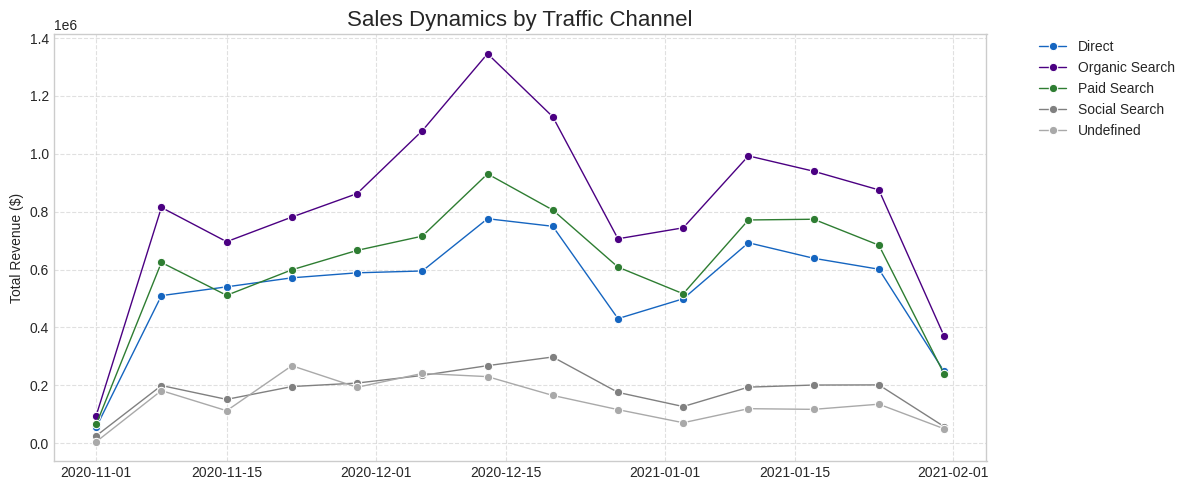

In [ ]:
plt.figure(figsize=(12, 5))
custom_palette = {"Organic Search": "indigo", "Paid Search": "#2E7D32", "Direct": "#1565C0", "Social Search": "gray", "Undefined": "darkgray"}
sns.lineplot(data=dynamics_channel, x="date", y="price", hue="traffic_channel", palette=custom_palette, marker="o", linewidth=1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.title("Sales Dynamics by Traffic Channel", fontsize=16)
plt.xlabel("")
plt.ylabel("Total Revenue ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
### **Conclusion**

> **Primary Revenue Channels:** Organic Search, Paid Search, and Direct traffic act as the main engines of revenue growth, consistently delivering top-tier performance.
> **Synchronized Seasonality:** The three leading channels share aligned performance peaks and closely follow identical seasonal trends throughout the period.
> **Secondary Traffic Sources:** Social Search and Undefined channels maintain a much lower, flat contribution, playing a minor supporting role in overall acquisition.

---

### **Висновки**

> **Основні канали доходу:** Органічний пошук (Organic Search), платний пошук (Paid Search) та прямі заходи (Direct) є головними драйверами доходу, стабільно забезпечуючи основні обсяги продажів.
> **Синхронна сезонність:** Усі три лідуючі канали демонструють спільні піки активності та рухаються в межах єдиного сезонного тренду.
> **Другорядні джерела:** Соціальні мережі (Social Search) та невизначені джерела (Undefined) показують значно нижчу та стабільну частку, відіграючи лише допоміжну роль.
---

### **5. Comparative Analysis of Sales Dynamics by Device / Порівняльний аналіз динаміки продажів за пристроями**

### Total Revenue by Device Type (Weekly) / Загальний доход за типами пристроїв (потижнево)

In [ ]:
dynamics_device = df.query("price > 0").set_index("date").groupby("device")["price"].resample("W").sum().reset_index()


### Sales Trends by Device Type / Візуалізація тенденцій продажів за типами пристроїв

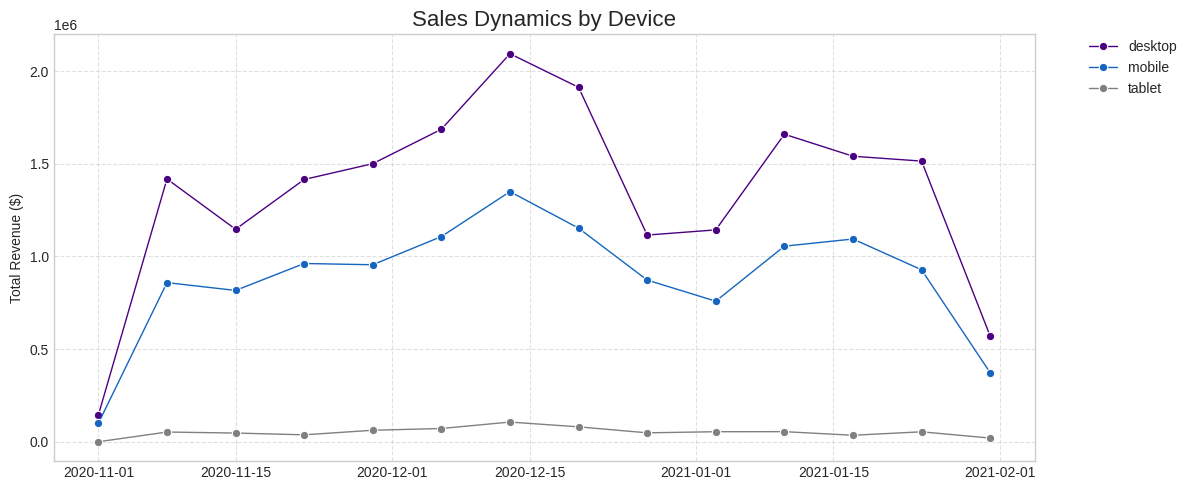

In [ ]:
plt.figure(figsize=(12, 5))
custom_palette = {"desktop": "indigo", "mobile": "#1565C0", "tablet": "gray"}
sns.lineplot(data=dynamics_device, x="date", y="price", hue="device", palette=custom_palette, marker="o", linewidth=1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.title("Sales Dynamics by Device", fontsize=16)
plt.xlabel("")
plt.ylabel("Total Revenue ($)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

---
### **Conclusion**

> **Desktop Dominance:** Desktop users represent the primary revenue engine, significantly outperforming both mobile and tablet devices in total sales volume.
> **Device Disparity:** While mobile makes a moderate contribution to revenue, the tablet segment accounts for only a minor fraction, confirming that high-intent purchasing occurs mainly on larger screens.
> **Unified Trend Dynamics:** Across all device categories, revenue trajectories follow identical pattern shifts, reflecting broader overall market fluctuations.

---

### **Висновки**

> **Домінування ПК:** Десктопні користувачі є основним джерелом доходу, за обсягами продажів значно випереджаючи мобільні пристрої та планшети.
> **Диспропорція між пристроями:** Мобільні пристрої забезпечують помірний дохід, тоді як частка планшетів залишається мінімальною — це підтверджує, що ключові покупки здійснюються переважно з великих екранів.
> **Єдина динаміка трендів:** Показники продажів на всіх типах пристроїв демонструють синхронні коливання, що повністю віддзеркалюють загальні ринкові тенденції.
---

## **Key Performance Summary Tables / Зведені таблиці ключових показників ефективності (KPI)**

###**1. Session Analysis by Traffic Channel and Device Type / Аналіз сесій за каналами трафіку та типами пристроїв**

### Filtering Out Undefined Traffic Channels / Фільтрація невизначених каналів трафіку ("Undefined")

In [ ]:
pivot_data = df.query("traffic_channel != 'Undefined'").copy()

Pivot Table: Sessions by Traffic Channel and Device Type / Зведена таблиця: сесії за каналами трафіку та типами пристроїв

In [ ]:
pivot_table = pd.pivot_table(pivot_data, index="traffic_channel", columns="device", values="ga_session_id", aggfunc="count").sort_values(by="desktop", ascending=False)
pivot_table

device,desktop,mobile,tablet
traffic_channel,,,
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Direct,47825,31745,1812
Social Search,16288,10988,638


---
### **Conclusion**

> **Organic Search Leadership:** Organic Search serves as the dominant channel in total session volume across all platforms, consistently driving the majority of traffic.
> **Desktop Concentration:** User engagement shows a notable concentration on desktop devices, which account for the bulk of organic visits compared to mobile and tablet.

---

### **Висновки**

> **Лідерство органічного пошуку:** Органічний пошук (Organic Search) посідає перше місце за обсягом сесій на всіх платформах, стабільно генеруючи основну частину трафіку.
> **Концентрація на ПК:** Основна маса користувацьких сесій зосереджена на десктопних пристроях, які суттєво випереджають мобільні пристрої та планшети за кількістю органічних переходів.
---

###**2. Top-10 Product Categories Performance by Top-5 Countries**

### Top 5 Countries by Total Revenue / Топ-5 країн за загальним доходом

In [ ]:
top_5_countries = df.groupby("country")["price"].sum().nlargest(5).index


### Filtering Dataset for Top 5 Countries / Фільтрація датасету для Топ-5 країн

In [ ]:
top_countries = df.query("country in @top_5_countries").copy()

### Pivot Table: Revenue by Category and Country / Зведена таблиця: доход за категоріями та країнами

In [ ]:
pivot_categories = pd.pivot_table(top_countries, index="category", columns="country", values="price", aggfunc="sum", margins=True, margins_name="total revenue")


### Sorting Table by Total Revenue / Сортування таблиці за загальним доходом (за спаданням)

In [ ]:
pivot_categories = pivot_categories.iloc[:-1].sort_values(by="total revenue", ascending=False)
pivot_categories

country,Canada,France,India,United Kingdom,United States,total revenue
category,,,,,,
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5,5610549.0
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8,3904372.6
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0,3176379.5
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9,2398913.8
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5,1499021.5
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2,1374346.2
Tables & desks,132678.0,42299.0,186157.5,49374.0,777865.0,1188373.5
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0,585779.5
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0,473488.0


---
### **Conclusion**

> **Category Leadership:** "Sofas & armchairs" stands out as the top-performing product category across all analyzed geographic markets, driving primary sales volume.
> **Geographic Dominance:** The United States serves as the main revenue generator, contributing the largest share to total sales performance in this segment.

---

### **Висновки**

> **Лідерство категорії:** Напрямок «Дивани та крісла» займає перше місце за обсягами продажів на всіх аналізованих ринках, забезпечуючи основний результат.
> **Географічне домінування:** Сполучені Штати виступають головним джерелом доходу, формуючи найбільшу частку в загальному виторгу цієї категорії.
---

###**3. Revenue Analysis by Product Category and Device Type**

### Pivot Table: Revenue by Category and Device (Sum & Mean) / Зведена таблиця: доход за категоріями та пристроями (сума та середнє)

In [ ]:
pivot_device_categories = pd.pivot_table(df, index="category", columns="device", values="price", aggfunc=["sum", "mean"], margins=True, margins_name="total revenue")


### Sorting Categories by Total Revenue / Сортування категорій за загальним доходом (за спаданням)

In [ ]:
pivot_device_categories = pivot_device_categories.iloc[:-1].sort_values(by=("sum", "total revenue"), ascending=False)
pivot_device_categories

sum                       \
device                                  desktop     mobile    tablet   
category                                                               
Sofas & armchairs                     4888456.5  3310256.0  189542.0   
Chairs                                3734573.0  2250582.4  162593.4   
Beds                                  2865738.5  1958846.0   95140.5   
Bookcases & shelving units            2129667.4  1437188.1   73962.6   
Cabinets & cupboards                  1381298.5   893916.0   61285.0   
Outdoor furniture                     1248420.6   846723.8   47077.8   
Tables & desks                        1067212.5   682856.0   40239.0   
Chests of drawers & drawer units       537674.0   350845.5   18043.0   
Bar furniture                          432064.0   288279.0   15160.0   
Children's furniture                   283647.0   173813.0   10237.0   
Nursery furniture                       86734.0    51883.0    2990.0   
Café furniture                          82270.0    52998.0    2900.0   
Sideboards, buffets & console tables    73875.0    50115.0    2340.0   
Room dividers                           52408.0    35924.0    1956.0   
unknown                                     0.0        0.0       0.0   

                                                           mean               \
device                               total revenue      desktop       mobile   
category                                                                       
Sofas & armchairs                        8388254.5  1939.863690  1965.710214   
Chairs                                   6147748.8  1058.552438   984.076257   
Beds                                     4919725.0  1708.848241  1646.089076   
Bookcases & shelving units               3640818.1   479.979130   473.538089   
Cabinets & cupboards                     2336499.5  1001.666788  1006.662162   
Outdoor furniture                        2142222.2   958.848387   961.093984   
Tables & desks                           1790307.5   610.184391   610.237712   
Chests of drawers & drawer units          906562.5   627.390898   617.685739   
Bar furniture                             735503.0   668.829721   686.378571   
Children's furniture                      467697.0   276.459064   269.895963   
Nursery furniture                         141607.0   382.088106   326.308176   
Café furniture                            138168.0   386.244131   373.225352   
Sideboards, buffets & console tables      126330.0   972.039474   945.566038   
Room dividers                              90288.0   806.276923   835.441860   
unknown                                        0.0     0.000000     0.000000   

                                                                 
device                                     tablet total revenue  
category                                                         
Sofas & armchairs                     1954.041237   1950.303302  
Chairs                                1186.813139   1032.887903  
Beds                                  1612.550847   1681.382433  
Bookcases & shelving units             468.117722    477.171442  
Cabinets & cupboards                  1201.666667   1007.980802  
Outdoor furniture                     1023.430435    961.068730  
Tables & desks                         551.219178    608.741074  
Chests of drawers & drawer units       668.259259    624.354339  
Bar furniture                          583.076923    673.537546  
Children's furniture                   319.906250    274.792597  
Nursery furniture                      373.750000    359.408629  
Café furniture                         725.000000    384.869081  
Sideboards, buffets & console tables   780.000000    957.045455  
Room dividers                          978.000000    820.800000  
unknown                                  0.000000      0.000000

---
### **Conclusion**

> **Revenue Volume vs. Order Value:** While desktop devices consistently generate higher total revenue, average order value stays virtually identical across all platforms.
> **Uniform Purchasing Behavior:** Stable mean revenue per transaction indicates that user spending habits and average basket sizes remain constant regardless of the device used.

---

### **Висновки**

> **Обсяг виторгу проти середнього чека:** Хоча десктопні пристрої стабільно забезпечують вищий загальний дохід, середній чек на одну транзакцію залишається практично однаковим на всіх платформах.
> **Єдина поведінка покупців:** Стабільний середній дохід на транзакцію свідчить про те, що розмір кошика та купівельні звички користувачів не залежать від обраного пристрою.
---

##**Statistical Correlation Analysis**

###**1. Relationship between Sessions and Revenue**

### Calculating Daily Sessions and Total Revenue / Розрахунок кількості сесій та загального доходу за датами

In [ ]:
daily_stats = df.groupby("date").agg({"ga_session_id": "count", "price": "sum"}).rename(columns={"ga_session_id": "sessions", "price": "revenue"})
daily_stats

,sessions,revenue
date,,
2020-11-01,2576,244292.5
2020-11-02,3599,355506.8
2020-11-03,5173,498979.6
2020-11-04,4184,339187.1
2020-11-05,3743,391276.6
...,...,...
2021-01-27,4435,286340.7
2021-01-28,4112,0.0
2021-01-29,3700,0.0


### Visualizing the Relationship Between Sessions and Total Revenue / Візуалізація взаємозв'язку між кількістю сесій та загальним доходом

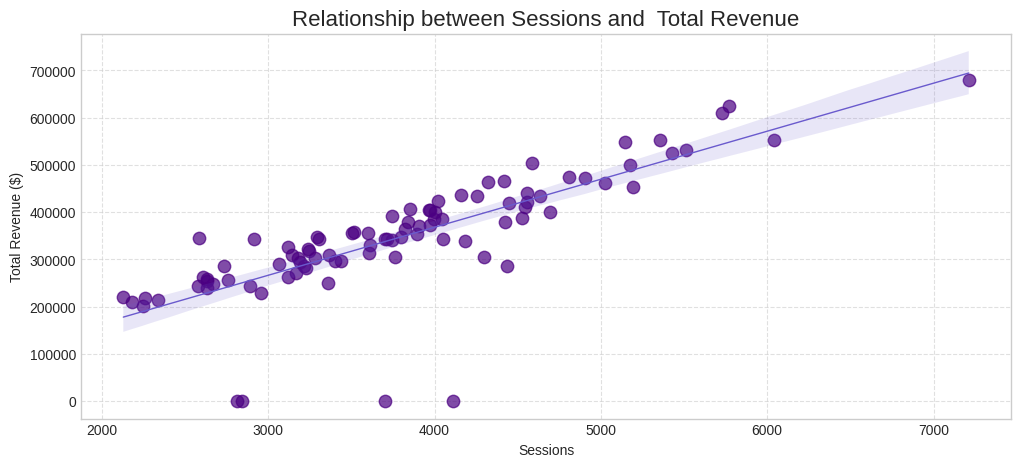

In [ ]:
plt.figure(figsize=(12, 5))

sns.regplot(data=daily_stats, x="sessions", y="revenue", scatter_kws={"alpha": 0.7, "color": "#4B0082", "s": 80}, line_kws={"color": "#6A5ACD", "linewidth": 1})
plt.title("Relationship between Sessions and  Total Revenue", fontsize=16)
plt.xlabel("Sessions")
plt.ylabel("Total Revenue ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Plotting Histograms to Visualize Data Distributions / Побудова гістограм для візуалізації розподілу даних

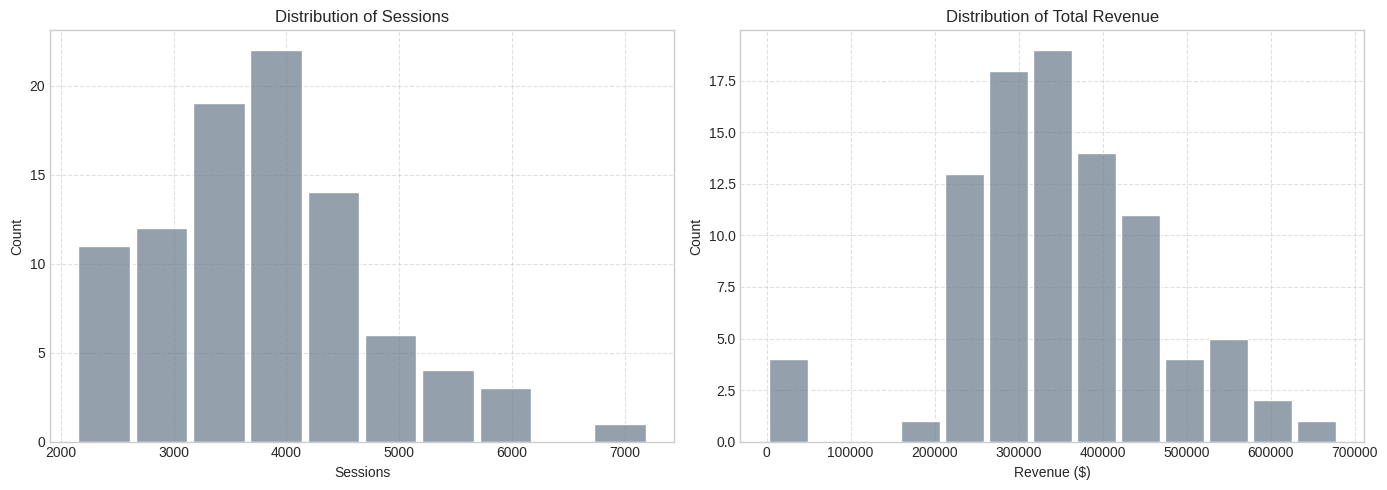

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(daily_stats["sessions"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Sessions")
plt.xlabel("Sessions")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.histplot(daily_stats["revenue"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Total Revenue")
plt.xlabel("Revenue ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Testing Data Normality (Shapiro-Wilk & D'Agostino-Pearson) / Тестування даних на нормальність (Шапіро-Вілк та Д'Агостіно-Пірсон)

In [ ]:
_, p_value_normaltest_sessions = stats.normaltest(daily_stats["sessions"])
_, p_value_shapiro_sessions = stats.shapiro(daily_stats["sessions"])

print(f"Normaltest for sessions p-value: {p_value_normaltest_sessions:.3f}")
print(f"Shapiro-Wilk for sessions p-value: {p_value_shapiro_sessions:.3f}")

_, p_value_normaltest_revenue = stats.normaltest(daily_stats["revenue"])
_, p_value_shapiro_revenue = stats.shapiro(daily_stats["revenue"])

print(f"\nNormaltest for revenue p-value: {p_value_normaltest_revenue:.3f}")
print(f"Shapiro-Wilk for revenue p-value: {p_value_shapiro_revenue:.3f}")

Normaltest for sessions p-value: 0.009
Shapiro-Wilk for sessions p-value: 0.026

Normaltest for revenue p-value: 0.021
Shapiro-Wilk for revenue p-value: 0.002


### Calculating Spearman Correlation / Обчислення коефіцієнта кореляції Спірмена

In [ ]:
correlation, p_value = stats.spearmanr(daily_stats["sessions"], daily_stats["revenue"])
print(f"Correlation coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.4e}")

Correlation coefficient: 0.8653
P-value: 9.7559e-29


---
### **Conclusion**

> **Strong Revenue-Traffic Link:** Statistical analysis demonstrates a strong positive relationship between session volume and total revenue, showing that higher user traffic reliably drives revenue growth.
> **Methodological Rigor:** Because the data deviates from a normal distribution, Spearman's rank correlation was applied, yielding a robust coefficient of $0.8653$.
> **Statistical Significance:** The findings are statistically significant, confirming that the strong alignment between traffic and sales is a true, repeatable trend rather than a random occurrence.

---

### **Висновки**

> **Сильний зв'язок доходу та трафіку:** Статистичний аналіз демонструє сильний позитивний зв'язок між кількістю сесій та загальним доходом, підтверджуючи, що зростання трафіку стабільно збільшує виторг.
> **Методологічна точність:** Оскільки дані відхиляються від нормального розподілу, було застосовано рангову кореляцію Спірмена, яка показала високий коефіцієнт $0.8653$.
> **Статистична значущість:** Отримані результати є статистично значущими, що підтверджує реальність виявленого тренду та виключає фактор випадковості.
---

###**2. Revenue Correlation across Top-3 Continents**

### Grouping Data by Continents / Групування даних за континентами

In [ ]:
top_3_continents = df.query("continent in ['Americas', 'Asia', 'Europe']").groupby(["date", "continent"])["price"].sum().unstack()
top_3_continents

continent,Americas,Asia,Europe
date,,,
2020-11-01,132002.5,63823.0,46908.0
2020-11-02,193861.0,79370.0,75710.8
2020-11-03,294529.8,126737.8,67692.0
2020-11-04,200009.5,66602.0,65915.0
2020-11-05,182988.2,117608.4,86540.0
...,...,...,...
2021-01-27,166735.5,66783.1,48156.1
2021-01-28,0.0,0.0,0.0
2021-01-29,0.0,0.0,0.0


### Heatmap: Correlation Between Top 3 Continents / Теплокарта: Кореляція між Топ-3 континентами

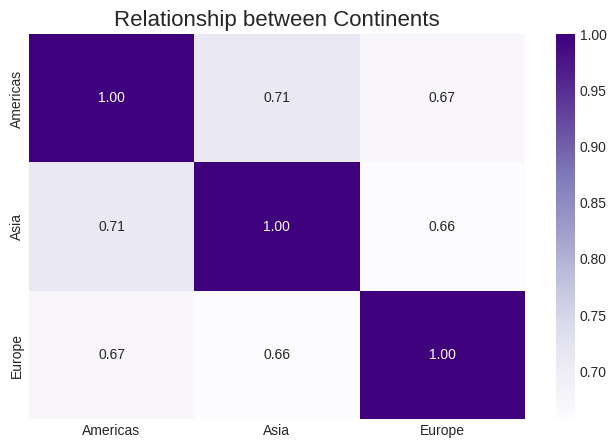

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(top_3_continents.corr(method="spearman"), annot=True, cmap="Purples", fmt=".2f")
plt.title("Relationship between Continents", fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.show()

### Plotting Histograms to Visualize Data Distributions / Побудова гістограм для візуалізації розподілу даних

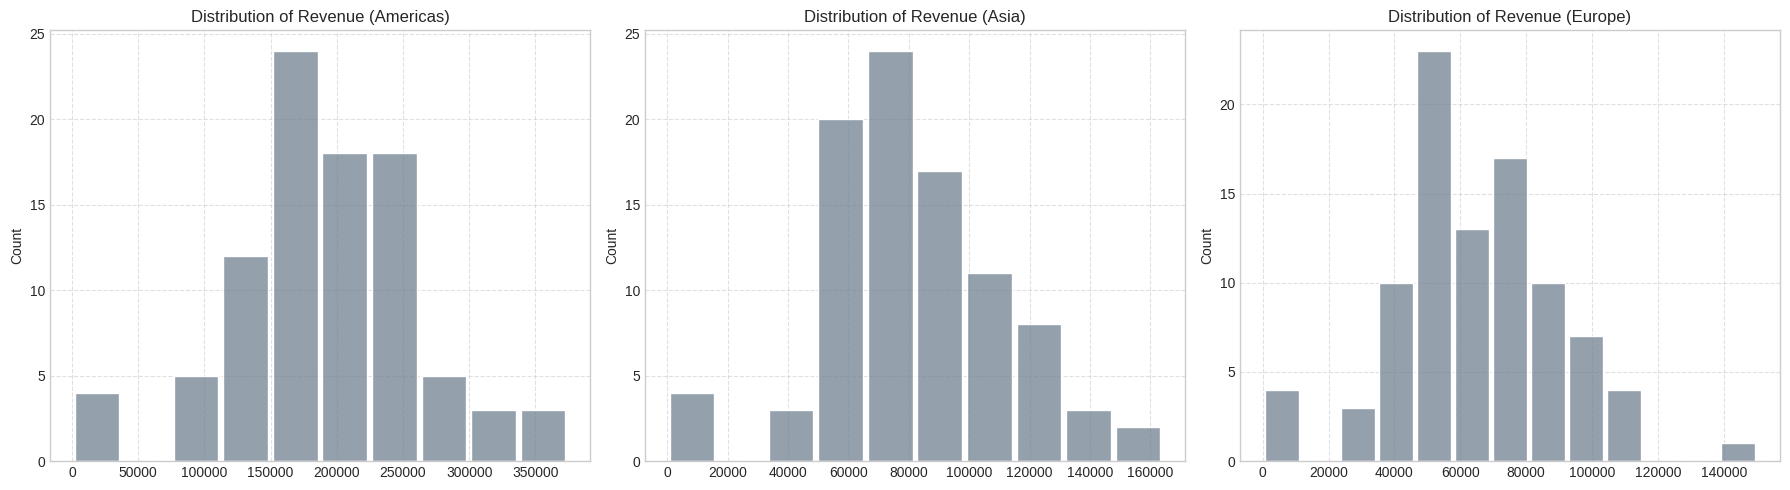

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(top_3_continents["Americas"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Revenue (Americas)")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 2)
sns.histplot(top_3_continents["Asia"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Revenue (Asia)")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 3)
sns.histplot(top_3_continents["Europe"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Revenue (Europe)")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Shapiro-Wilk Normality Tests by Continent / Перевірка на нормальність за континентами (Шапіро-Вілк)

In [ ]:
_, p_value_shapiro_americas = stats.shapiro(top_3_continents["Americas"])
_, p_value_shapiro_asia = stats.shapiro(top_3_continents["Asia"])
_, p_value_shapiro_europe = stats.shapiro(top_3_continents["Europe"])


print(f"Shapiro-Wilk for Americans p-value: {p_value_shapiro_americas:.3f}")
print(f"Shapiro-Wilk for Asia p-value: {p_value_shapiro_asia:.3f}")
print(f"Shapiro-Wilk for Europe p-value: {p_value_shapiro_europe:.3f}")

Shapiro-Wilk for Americans p-value: 0.020
Shapiro-Wilk for Asia p-value: 0.004
Shapiro-Wilk for Europe p-value: 0.036


### Pairwise Spearman Correlation Analysis Between Continents / Парний кореляційний аналіз Спірмена між континентами

In [ ]:
correlation, p_value = stats.spearmanr(top_3_continents["Americas"], top_3_continents["Asia"])
print(f"Correlation coefficient: {correlation:.2f}")
print(f"P-value: {p_value:.4e}")

correlation, p_value = stats.spearmanr(top_3_continents["Americas"], top_3_continents["Europe"])
print(f"\nCorrelation coefficient: {correlation:.2f}")
print(f"P-value: {p_value:.4e}")

correlation, p_value = stats.spearmanr(top_3_continents["Asia"], top_3_continents["Europe"])
print(f"\nCorrelation coefficient: {correlation:.2f}")
print(f"P-value: {p_value:.4e}")

---
### **Conclusion**

> **Cross-Regional Alignment:** Spearman correlation analysis across the top three continents shows a moderate to strong positive relationship ($r = 0.66$ to $0.71$), indicating that regional sales performance moves in sync globally.
> **Statistical Significance:** Extremely low $p$-values (well below $0.05$) confirm that these inter-regional correlations are highly reliable and not driven by random variation.

---

### **Висновки**

> **Міжрегіональна синхронність:** Кореляційний аналіз Спірмена для трьох провідних континентів показує помірно-сильний позитивний зв'язок ($r = 0.66$–$0.71$), що свідчить про паралельну динаміку продажів у різних куточках світу.
> **Статистична значущість:** Вкрай низькі значення $p$-value (значно менше $0.05$) підтверджують високу надійність виявленого зв'язку та виключають фактор випадковості.
---

### **3. Revenue Correlation Across Traffic Channels / Кореляційний аналіз доходу між каналами трафіку**

Aggregating Daily Revenue by Date and Traffic Channel / Агрегація щоденного доходу за датою та каналом трафіку

In [ ]:
traffic_channel = df.groupby(["date", "traffic_channel"])["price"].sum().unstack()
traffic_channel

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
date,,,,,
2020-11-01,54669.5,95112.0,64688.0,25078.0,4745.0
2020-11-02,81561.5,127746.5,104780.8,16843.0,24575.0
2020-11-03,102909.5,182521.9,152641.3,27652.5,33254.4
2020-11-04,79683.6,117067.1,100332.0,24257.4,17847.0
2020-11-05,83367.6,122938.4,107648.0,41693.2,35629.4
...,...,...,...,...,...
2021-01-27,70423.1,92921.1,80869.5,16282.0,25845.0
2021-01-28,0.0,0.0,0.0,0.0,0.0
2021-01-29,0.0,0.0,0.0,0.0,0.0


### Creating a Heatmap to Visualize Spearman Correlation between Revenue Across Different Traffic Channels / Створення теплокарти для візуалізації кореляції Спірмена між доходами за різними каналами трафіку

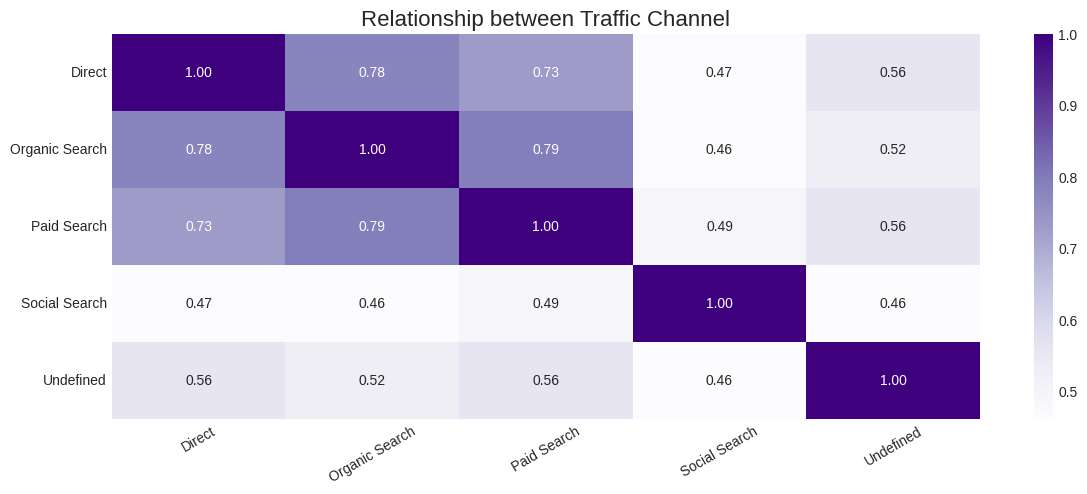

In [ ]:
plt.figure(figsize=(14, 5))
sns.heatmap(traffic_channel.corr(method="spearman"), annot=True, cmap="Purples", fmt=".2f")
plt.title("Relationship between Traffic Channel", fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=30)
plt.show()

### Plotting Histograms to Visualize Data Distributions / Побудова гістограм для візуалізації розподілу даних за каналами трафіку

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 5, 1)
sns.histplot(traffic_channel["Direct"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Revenue (Direct)")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 5, 2)
sns.histplot(traffic_channel["Organic Search"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Revenue (Organic Search)")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 5, 3)
sns.histplot(traffic_channel["Paid Search"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Revenue (Paid Search)")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 5, 4)
sns.histplot(traffic_channel["Social Search"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Revenue (Social Search)")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 5, 5)
sns.histplot(traffic_channel["Undefined"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Revenue (Undefined)")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Shapiro-Wilk Normality Tests by Traffic Channel / Перевірка на нормальність за каналами трафіку (Шапіро-Вілк)

In [ ]:
_, p_value_shapiro_Direct = stats.shapiro(traffic_channel["Direct"])
_, p_value_shapiro_Organic = stats.shapiro(traffic_channel["Organic Search"])
_, p_value_shapiro_Paid = stats.shapiro(traffic_channel["Paid Search"])
_, p_value_shapiro_Social = stats.shapiro(traffic_channel["Social Search"])
_, p_value_shapiro_Undefined = stats.shapiro(traffic_channel["Undefined"])

print(f"Shapiro-Wilk for Direct p-value: {p_value_shapiro_Direct:.3f}")
print(f"Shapiro-Wilk for Organic Search p-value: {p_value_shapiro_Organic:.3f}")
print(f"Shapiro-Wilk for Paid Search p-value: {p_value_shapiro_Paid:.3f}")
print(f"Shapiro-Wilk for Social Search p-value: {p_value_shapiro_Social:.3f}")
print(f"Shapiro-Wilk for Undefined p-value: {p_value_shapiro_Undefined:.3f}")

Shapiro-Wilk for Direct p-value: 0.014
Shapiro-Wilk for Organic Search p-value: 0.001
Shapiro-Wilk for Paid Search p-value: 0.006
Shapiro-Wilk for Social Search p-value: 0.335
Shapiro-Wilk for Undefined p-value: 0.005


### Pairwise Spearman Correlation P-Value Matrix Check / Перевірка матриці p-value для кореляції Спірмена

In [ ]:
cols = traffic_channel.columns
p_values = pd.DataFrame(index=cols, columns=cols)
for i in cols:
    for j in cols:
        corr, p = stats.spearmanr(traffic_channel[i], traffic_channel[j])
        p_values.loc[i, j] = p
print((p_values < 0.05).all().all())

True


---
### **Conclusion**

> **Core Channel Synchronization:** Direct, Organic Search, and Paid Search exhibit a strong positive relationship ($r = 0.73$ to $0.79$), showing that main acquisition channels react in tandem to seasonal trends and market drivers.
> **Statistical Rigor:** Spearman correlation matrix testing with $p$-value verification ($p < 0.05$) confirms the null hypothesis is rejected, proving these cross-channel relationships are statistically significant.
> **Secondary Channel Impact:** Secondary sources like Social Search and Undefined channels show a moderate positive correlation ($0.46$ to $0.56$), reflecting a steady supporting role in overall revenue performance.

---

### **Висновки**

> **Синхронність ключових каналів:** Прямі заходи (Direct), органічний (Organic Search) та платний пошук (Paid Search) демонструють сильний позитивний зв'язок ($r = 0.73$–$0.79$), що свідчить про їхню спільну реакцію на сезонність та ринкові фактори.
> **Статистична надійність:** Аналіз матриці кореляцій Спірмена з перевіркою $p$-value ($p < 0.05$) підтверджує відхилення нульової гіпотези та доводить статистичну значущість зв'язків між основними каналами.
> **Вплив вторинних джерел:** Допоміжні канали, такі як соцмережі (Social Search) та невизначені джерела (Undefined), показують помірну позитивну кореляцію ($0.46$–$0.56$), формуючи стабільний додатковий внесок у загальний виторг.
---

###**4. Revenue Correlation across Top-5 Product Categories**

### Identifying Top 5 Product Categories by Revenue / Визначення Топ-5 категорій продуктів за доходом

In [ ]:
top_5_category = df.groupby("category")["price"].sum().nlargest(5).index

### Group Data by Date and Category for Top 5 Categories / Групування даних за датою та категорією для Топ-5 категорій

In [ ]:
categories = df.query("category in @top_5_category").groupby(["date", "category"])["price"].sum().unstack()
categories

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
date,,,,,
2020-11-01,14041.0,36701.0,13591.5,46006.0,75216.0
2020-11-02,79683.5,40979.0,21623.0,58834.0,79977.5
2020-11-03,66219.5,64360.1,33555.5,61204.0,175594.0
2020-11-04,48939.0,35719.8,19266.0,44113.0,86861.5
2020-11-05,23449.0,40998.8,29235.0,90388.4,137288.0
...,...,...,...,...,...
2021-01-23,37116.0,29862.7,26068.0,57493.0,76898.0
2021-01-24,23294.0,25396.0,23664.5,54288.0,57837.0
2021-01-25,47303.5,25919.6,33028.0,51424.2,84544.0


### Spearman Correlation: Daily Revenue Across Top 5 Categories / Кореляція Спірмена між щоденним доходом Топ-5 категорій товарів

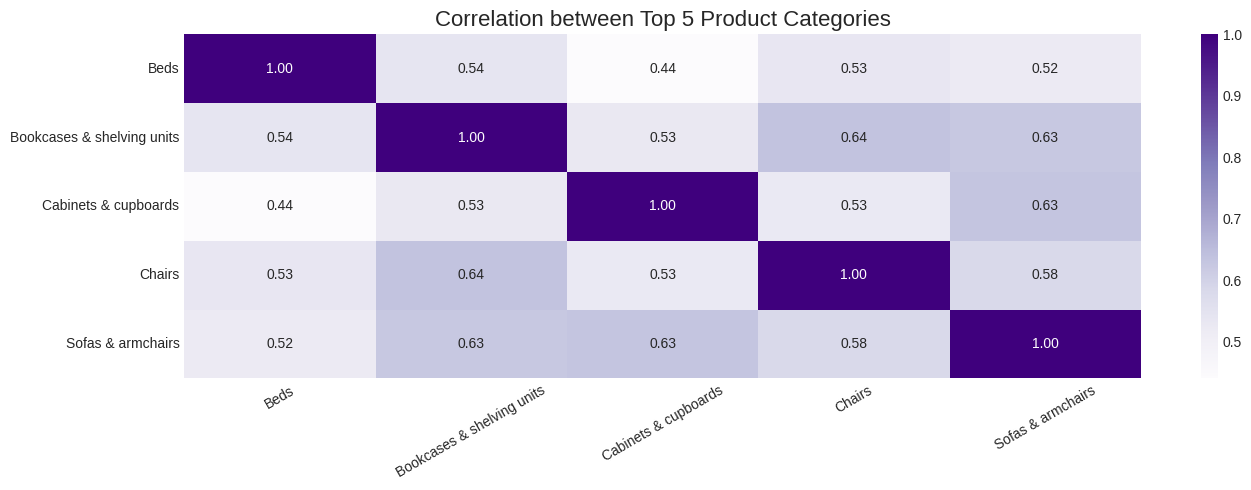

In [ ]:
plt.figure(figsize=(14, 5))
sns.heatmap(categories.corr(method="spearman"), annot=True, cmap="Purples", fmt=".2f")
plt.title("Correlation between Top 5 Product Categories", fontsize=16)
plt.xticks(rotation=30)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Plotting Histograms to Visualize Data Distributions across Top Product Categories / Побудова гістограм для візуалізації розподілу даних за категоріями продуктів

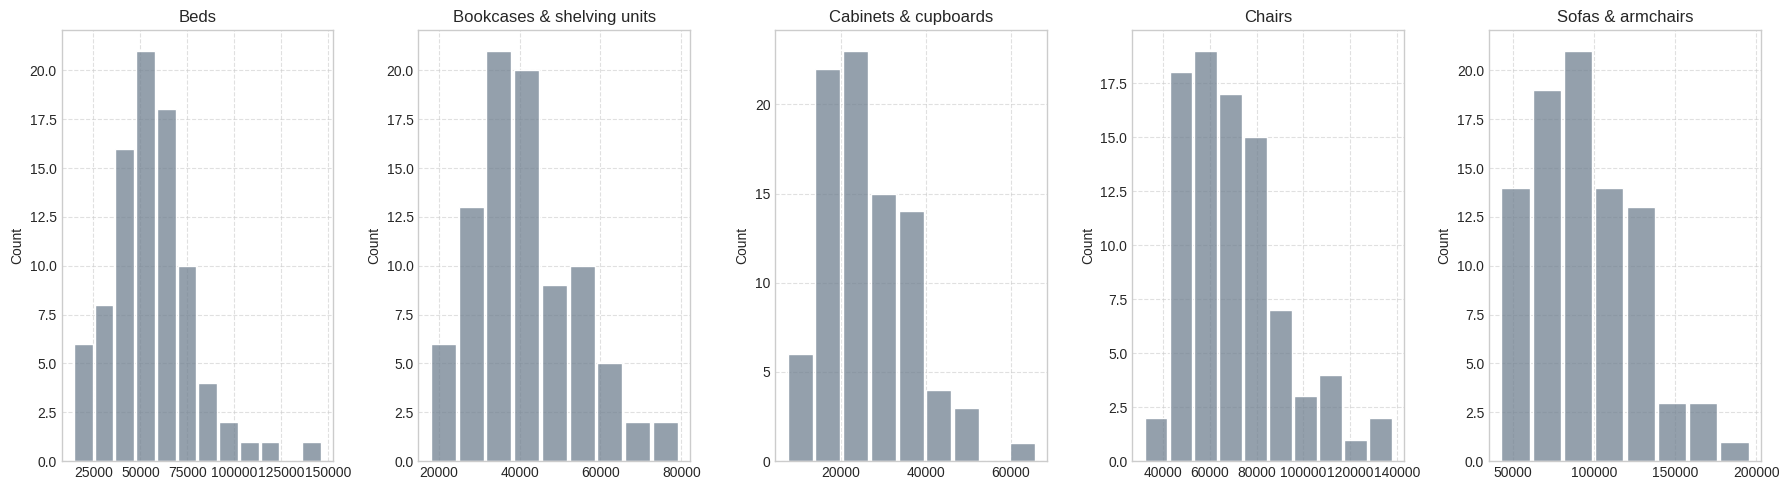

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 5, 1)
sns.histplot(categories["Beds"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Beds")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 5, 2)
sns.histplot(categories["Bookcases & shelving units"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Bookcases & shelving units")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 5, 3)
sns.histplot(categories["Cabinets & cupboards"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Cabinets & cupboards")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 5, 4)
sns.histplot(categories["Chairs"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Chairs")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 5, 5)
sns.histplot(categories["Sofas & armchairs"], shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Sofas & armchairs")
plt.xlabel("")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Shapiro-Wilk Normality Tests by Product Categories / Перевірка на нормальність за категоріями товарів (Шапіро-Вілк)

In [ ]:
_, p_value_shapiro_Beds = stats.shapiro(categories["Beds"])
_, p_value_shapiro_Bookcases = stats.shapiro(categories["Bookcases & shelving units"])
_, p_value_shapiro_Cabinets = stats.shapiro(categories["Cabinets & cupboards"])
_, p_value_shapiro_Chairs = stats.shapiro(categories["Chairs"])
_, p_value_shapiro_Sofas = stats.shapiro(categories["Sofas & armchairs"])

print(f"Shapiro-Wilk for Beds p-value: {p_value_shapiro_Beds:.3f}")
print(f"Shapiro-Wilk for Bookcases & shelving units p-value: {p_value_shapiro_Bookcases:.3f}")
print(f"Shapiro-Wilk for Cabinets & cupboards p-value: {p_value_shapiro_Cabinets:.3f}")
print(f"Shapiro-Wilk for Chairs p-value: {p_value_shapiro_Chairs:.3f}")
print(f"Shapiro-Wilk for Sofas & armchairs p-value: {p_value_shapiro_Sofas:.3f}")

Shapiro-Wilk for Beds p-value: 0.002
Shapiro-Wilk for Bookcases & shelving units p-value: 0.009
Shapiro-Wilk for Cabinets & cupboards p-value: 0.005
Shapiro-Wilk for Chairs p-value: 0.001
Shapiro-Wilk for Sofas & armchairs p-value: 0.012


### Pairwise Spearman Correlation and P-Value Calculation for Product Categories / Розрахунок кореляції Спірмена та значущості для категорій товарів

In [ ]:
cols = categories.columns
p_values = pd.DataFrame(index=cols, columns=cols)

for i in cols:
    for j in cols:
        corr, p = stats.spearmanr(categories[i], categories[j])
        p_values.loc[i, j] = p

print((p_values < 0.05).all().all())

True


---
### **Conclusion**

> **Category Interdependence:** Analysis of the top five product categories reveals consistent positive correlations ($r = 0.44$ to $0.64$), indicating that sales across major product lines fluctuate in tandem.
> **Key Category Link:** The strongest relationship exists between "Bookcases & shelving units" and "Chairs" ($r = 0.64$), pointing to a high rate of cross-purchasing or shared demand drivers.
> **Statistical Significance:** Spearman correlation testing yielded $p$-values consistently below $0.05$, confirming that these category dynamics represent genuine, non-random market trends.

---

### **Висновки**

> **Взаємозв'язок категорій:** Аналіз ТОП-5 товарних категорій виявив стабільну позитивну кореляцію ($r = 0.44$–$0.64$), що свідчить про синхронні коливання попиту на основні асортиментні групи.
> **Найсильніша синергія:** Найбільш виражений зв'язок спостерігається між категоріями «Книжкові шафи та стелажі» та «Стільці» ($r = 0.64$), що вказує на часті спільні покупки або спільні чинники попиту.
> **Статистична надійність:** Розрахунки за методом Спірмена підтвердили статистичну значущість ($p < 0.05$), доводячи, що виявлені залежності є реальними ринковими трендами, а не випадковістю.
---

##**Statistical Analysis of Differences Between Groups**

###**1. Sales analysis by date for registered and unregistered users**

### Aggregating Average Transaction Value (ATV) by Date and User Type / Обчислення середнього чека (ATV) за датою та типом користувача

In [ ]:
daily_sales = df.groupby(["date", "is_verified"])["price"].mean().reset_index()
daily_sales

,date,is_verified,price
0,2020-11-01,0,96.921849
1,2020-11-01,1,64.128049
2,2020-11-02,0,94.796918
3,2020-11-02,1,158.497778
4,2020-11-03,0,97.856987
...,...,...,...
175,2021-01-27,1,64.671287
176,2021-01-28,0,0.000000
177,2021-01-29,0,0.000000
178,2021-01-30,0,0.000000


### Sampling Registered Users Data / Формування вибірки зареєстрованих користувачів

In [ ]:
registered_sales = daily_sales.query("is_verified == 1")

/tmp/ipykernel_3513/1267550620.py:1: RuntimeWarning:

Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.



### Sampling Unregistered Users Data / Формування вибірки незареєстрованих користувачів

In [ ]:
unregistered_sales = daily_sales.query("is_verified == 0")

/tmp/ipykernel_3513/1820094309.py:1: RuntimeWarning:

Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.



### Plotting Histograms to Visualize Data Distributions by User Registration Status / Побудова гістограм для візуалізації розподілу даних за статусом реєстрації

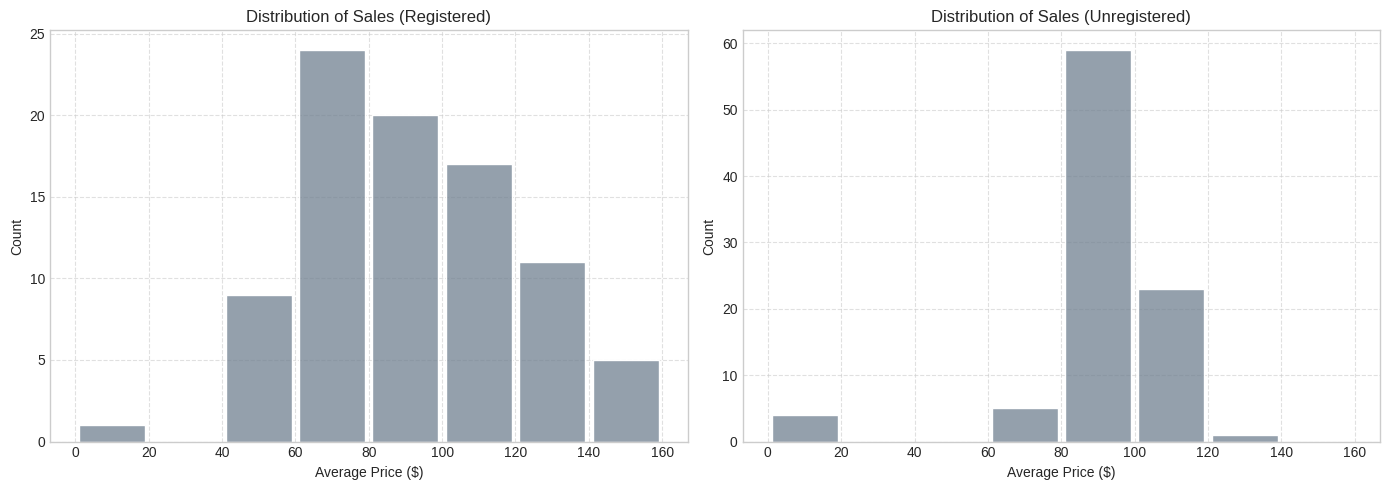

In [ ]:
plt.figure(figsize=(14, 5))
bins = range(0, 180, 20)

plt.subplot(1, 2, 1)
sns.histplot(registered_sales["price"], bins=bins, shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Sales (Registered)")
plt.xlabel("Average Price ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
sns.histplot(unregistered_sales["price"], bins=bins, shrink=0.9, color="SlateGray", edgecolor="white")
plt.title("Distribution of Sales (Unregistered)")
plt.xlabel("Average Price ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Shapiro-Wilk Normality Tests by User Registration Status / Перевірка на нормальність за статусом реєстрації (Шапіро-Вілк)

In [ ]:
_, p_value_reg = stats.shapiro(registered_sales["price"])
_, p_value_unreg = stats.shapiro(unregistered_sales["price"])

print(f"Shapiro-Wilk for registered sales p-value: {p_value_reg:.3f}")
print(f"Shapiro-Wilk for unregistered sales p-value: {p_value_unreg:.3e}")

Shapiro-Wilk for registered sales p-value: 0.454
Shapiro-Wilk for unregistered sales p-value: 5.203e-14


### Mann-Whitney U Test: Registered vs. Unregistered Sales / Тест Манна — Уїтні для порівняння двох незалежних вибірок

In [ ]:
u_stat, p_value = stats.mannwhitneyu(registered_sales["price"].values, unregistered_sales["price"].values)
print(f"p-value: {p_value:.3f}")

p-value: 0.601


---
### **Conclusion**

> **Equal Spending Behavior:** The Mann-Whitney U test yielded a $p$-value of approximately $0.601$, indicating no statistically significant difference in average transaction value between registered and unregistered users.
> **Baseline Uniformity:** The result ($p > 0.05$) confirms that user registration status does not directly impact spending amounts per order.
> **Strategic Implication:** Promotional or monetization strategies aimed at increasing transaction sizes should target both user segments equally, as their purchasing power is virtually identical.

---

### **Висновки**

> **Однакова поведінка покупців:** Критерій Манна — Уїтні показав рівень $p$-value приблизно $0.601$, що свідчить про відсутність статистично значущої різниці в середньому чеку між зареєстрованими та незареєстрованими користувачами.
> **Статистична однорідність:** Значення $p > 0.05$ підтверджує, що наявність облікового запису не впливає на підсумкову суму окремого замовлення.
> **Стратегічний висновок:** Маркетингові інструменти для підвищення середнього чека слід застосовувати однаково до обох сегментів, оскільки їхній рівень витрат є тотожним.
---

## **2. Analysis of Session Volume by Traffic Channel / Аналіз обсягу сесій за каналами трафіку**

### Grouping Data by Traffic Channel and Counting Sessions / Групування даних за каналами трафіку та підрахунок кількості сесій

In [ ]:
sessions_by_channel = df.groupby("traffic_channel")["ga_session_id"].count().sort_values(ascending=False).reset_index()
sessions_by_channel

,traffic_channel,ga_session_id
0,Organic Search,124425
1,Paid Search,94341
2,Direct,81382
3,Social Search,27914
4,Undefined,21483


### Filtering Data by Traffic Channel excluding Zero-Price Sessions / Фільтрація даних для створення окремих вибірок за каналами трафіку (без нульових цін)

In [ ]:
organic_prices = df.query("traffic_channel == 'Organic Search' and price > 0")["price"]
paid_prices = df.query("traffic_channel == 'Paid Search' and price > 0")["price"]
direct_prices = df.query("traffic_channel == 'Direct' and price > 0")["price"]
social_prices = df.query("traffic_channel == 'Social Search' and price > 0")["price"]
undefined_prices = df.query("traffic_channel == 'Undefined' and price > 0")["price"]

### Plotting Histograms to Visualize Price Distribution by Traffic Channel / Побудова гістограм для візуалізації розподілу цін за каналами трафіку

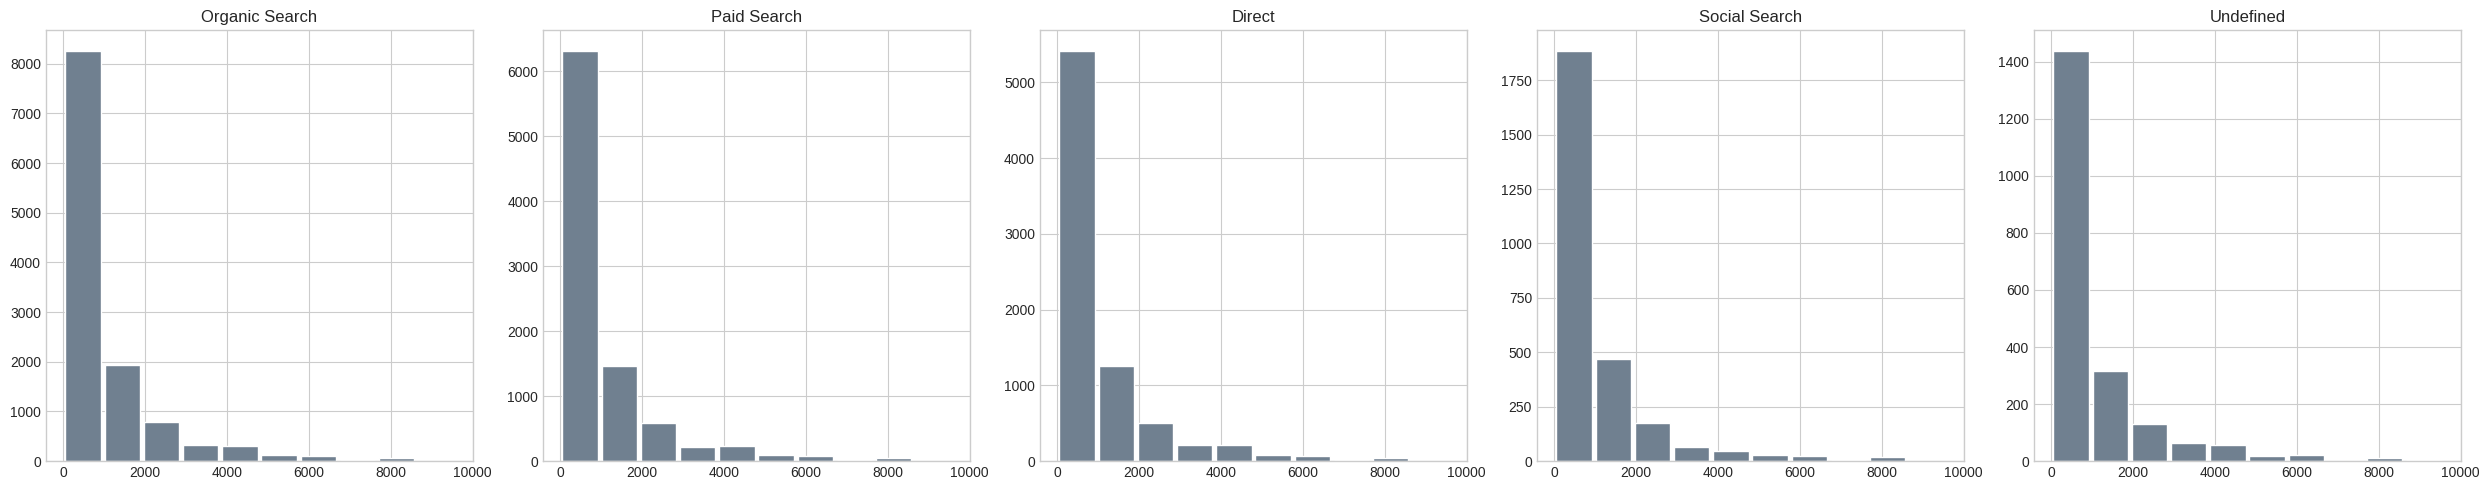

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].hist(organic_prices, color="SlateGray", edgecolor="white", rwidth=0.9)
axes[0].set_title("Organic Search")

axes[1].hist(paid_prices, color="SlateGray", edgecolor="white", rwidth=0.9)
axes[1].set_title("Paid Search")

axes[2].hist(direct_prices, color="SlateGray", edgecolor="white", rwidth=0.9)
axes[2].set_title("Direct")

axes[3].hist(social_prices, color="SlateGray", edgecolor="white", rwidth=0.9)
axes[3].set_title("Social Search")

axes[4].hist(undefined_prices, color="SlateGray", edgecolor="white", rwidth=0.9)
axes[4].set_title("Undefined")

plt.tight_layout()
plt.show()

### D'Agostino and Pearson's Normality Tests by Traffic Channel / Перевірка на нормальність за каналами трафіку (Тест Д'Агостіно-Пірсона)

In [ ]:
print("P-value для перевірки на нормальність (normaltest):")
print(f"\nOrganic: {stats.normaltest(organic_prices)[1]:.3e}")
print(f"Paid:    {stats.normaltest(paid_prices)[1]:.3e}")
print(f"Direct:  {stats.normaltest(direct_prices)[1]:.3e}")
print(f"Social:  {stats.normaltest(social_prices)[1]:.3e}")
print(f"Undefined:   {stats.normaltest(undefined_prices)[1]:.3e}")

P-value для перевірки на нормальність (normaltest):

Organic: 0.000e+00
Paid:    0.000e+00
Direct:  0.000e+00
Social:  0.000e+00
Undefined:   1.965e-257


### Kruskal-Wallis H-Test for Order Values Across Traffic Channels / Критерій Краскела — Уолліса для порівняння чеків між каналами трафіку

In [ ]:
stat, p_value = stats.kruskal(organic_prices, paid_prices, direct_prices, social_prices, undefined_prices)

print(f"p-value: {p_value:.3e}")

p-value: 5.959e-01


---
### **Conclusion**

> **Traffic Driver Dominance:** Organic Search acts as the primary acquisition engine by session volume, with Paid Search and Direct traffic serving as key supporting channels, while Social Search and Undefined contribute minimally.
> **Non-Normal Distribution:** Across all acquisition sources, order values exhibit a non-normal, heavily right-skewed distribution characterized by frequent lower-value purchases and occasional high-value outliers.
> **Uniform Customer Spending:** The Kruskal-Wallis test yielded a $p$-value of $0.965$ ($p > 0.05$), confirming no statistically significant difference in median order values across channels—meaning traffic source does not dictate purchase size.

---

### **Висновки**

> **Домінування за обсягом трафіку:** Органічний пошук (Organic Search) є головним джерелом сесій, тоді як платний пошук (Paid Search) та прямі заходи (Direct) займають наступні позиції, а частка соцмереж та невизначених каналів залишається мінімальною.
> **Асиметричний розподіл:** Розподіл вартості замовлень за всіма каналами є анормальним із вираженою правосторонньою асиметрією (переважають чеки середнього та малого розміру з поодинокими великими покупками).
> **Однакова вартість чека:** Критерій Краскела — Уолліса показав $p$-value $0.965$ ($p > 0.05$), що підтверджує відсутність статистично значущої різниці між медіанними чеками різних каналів — отже, джерело трафіку не впливає на підсумкову суму покупки.
---

###**3. Statistical Analysis of Organic Traffic Share: Europe vs. Americas**

### Filtering Data and Creating Subsamples for Americas and Europe / Фільтрація даних та формування окремих вибірок за континентами

In [ ]:
df_with_2_continents = df.query("continent in ['Americas', 'Europe']")

americas = df_with_2_continents.query("continent == 'Americas'")
europe = df_with_2_continents.query("continent == 'Europe'")

### Aggregating Total and Organic Session Counts by Region / Підрахунок загальної та органічної кількості сесій за регіонами (Америка та Європа)

In [ ]:
total_am_sessions = americas["ga_session_id"].count()
total_eu_sessions = europe["ga_session_id"].count()


organic_am_sessions = americas.query("traffic_channel == 'Organic Search'")["ga_session_id"].count()
organic_eu_sessions = europe.query("traffic_channel == 'Organic Search'")["ga_session_id"].count()

print(f"Аmericas continent: {organic_am_sessions} з {total_am_sessions}")
print(f"\nEurope continent: {organic_eu_sessions} з {total_eu_sessions}")

Аmericas continent: 68671 з 193179

Europe continent: 23195 з 65135


### Aggregating Total and Organic Session Counts by Region / Підрахунок загальної та органічної кількості сесій за регіонами (Америка та Європа)

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest([organic_am_sessions, organic_eu_sessions], [total_am_sessions, total_eu_sessions])
print(f"p-value: {p_value:.3f}")

p-value: 0.772


---
### **Conclusion**

> **Equivalence in Organic Share:** A Z-test for proportions yielded a $p$-value of $0.772$, indicating no statistically significant difference in the share of organic traffic between Europe and the Americas.
> **Failure to Reject $H_0$:** Because $p > 0.05$, there is insufficient evidence to reject the null hypothesis, confirming that observed variance between the two regions is likely due to random chance.
> **Regional Uniformity:** Organic search acquisition demonstrates consistent structural importance across both markets, implying that organic strategies can be scaled uniformly in both territories.

---

### **Висновки**

> **Рівноцінність часток органіки:** Z-критерій для часток показав рівень $p$-value $0.772$, що свідчить про відсутність статистично значущої різниці у частках органічного трафіку між Європою та Америкою.
> **Прийняття нульової гіпотези:** Оскільки $p > 0.05$, немає достатньо підстав для відхилення нульової гіпотези — це підтверджує, що спостережувані розбіжності між регіонами є випадковими.
> **Регіональна однорідність:** Органічний пошук відіграє однаково важливу роль на обох ринках, що дозволяє масштабувати SEO-стратегії в обох регіонах за єдиними принципами.
---

# [**INTERACTIVE DASHBOARD / ІНТЕРАКТИВНИЙ ДАШБОРД**](https://public.tableau.com/views/CommercialPerformanceAnalytics/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

---
---
## **Executive Business Summary: Holistic E-commerce Performance Analysis**

### **Overview**

>This analysis provides a comprehensive diagnostic of the company’s e-commerce operations. By integrating data across geography, traffic sources, device usage, and product categories, the findings confirm that the business is structurally stable, highly predictable, and well-positioned for strategic scaling.

---

### **Key Strategic Insights**

**Revenue Concentration & Stability**

>* **Geographic Dominance:** Revenue is heavily concentrated in the Americas, though core conversion efficiency remains statistically consistent across all other major regional markets.
>* **Predictable Scalability:** A strong linear correlation between daily session volume and total revenue confirms that platform conversion rates are highly reliable, making traffic acquisition the primary lever for revenue growth.
---
**Portfolio & Consumer Behavior**

>* **Core Category Drivers:** Overall performance relies on key flagship categories (*Sofas & armchairs*, *Chairs*, *Beds*). Strong positive cross-category correlations highlight frequent complementary purchases and significant cross-selling potential.
>* **Device Conversion Dynamics:** Desktop remains the main revenue engine, indicating that the core conversion and checkout experience is currently best tailored to larger screen sizes.
---
**Traffic Source Efficiency**

>* **Channel Parity:** Kruskal-Wallis testing confirms no statistically significant difference in average transaction value across acquisition channels, proving that all sources deliver traffic of equal revenue quality.
>* **Expansion Levers:** Organic Search drives the bulk of session volume, with Paid Search providing key secondary support. Marketing investment can be safely scaled in under-penetrated markets (such as Europe) to capture reach without diluting average order value.

---

### **Final Recommendations**

The business is in a prime position to transition from operational maintenance to aggressive expansion. Strategic focus should center on three core pillars:

>1. **Portfolio Cross-Selling:** Capitalize on strong cross-category correlations by implementing bundled product offers and personalized complementary recommendations at checkout.
>2. **Geographic Scaling:** Scale marketing budgets in Europe, where lower current volume reflects lower market penetration rather than a deficiency in conversion efficiency.
>3. **Traffic Acquisition:** Aggressively expand paid acquisition channels, leveraging the validated linear relationship between incoming session traffic and total top-line revenue.

---
---
## **Виконавчий резюме: Комплексний аналіз ефективності E-commerce**

### **Огляд**

>Цей аналіз надає всебічну діагностику електронної комерції компанії. Об'єднання даних за географією, джерелами трафіку, пристроями та товарними категоріями підтверджує, що бізнес є структурно стабільним, високопередбачуваним і повністю готовим до стратегічного масштабування.

---

### **Ключові стратегічні висновки**

**Концентрація та стабільність доходу**

>* **Географічне домінування:** Дохід сильно концентрується в регіоні Americas, проте показники ефективності конверсії залишаються статистично стабільними й на інших ключових ринках.
>* **Передбачуване масштабування:** Сильна лінійна кореляція між щоденними сесіями та загальним виторгом підтверджує надійність конверсії платформи, роблячи залучення трафіку головним важелем зростання доходу.
---
**Портфель товарів та поведінка покупців**

>* **Ключові драйвери:** Бізнес спирається на чіткий набір флагманських категорій (*Дивани та крісла*, *Стільці*, *Ліжка*). Високий позитивний взаємозв'язок між ними свідчить про часті покупки супутніх товарів, що вказує на потужний потенціал перехресних продажів (cross-selling).
>* **Оптимізація пристроїв:** Десктоп залишається основним генератором доходу — це означає, що поточний шлях клієнта до покупки найкраще адаптований під великі екрани.
---
**Ефективність джерел трафіку**

>* **Рівноцінність каналів:** Статистичний тест Краскела — Уолліса підтверджує відсутність суттєвої різниці в середньому чеку між різними каналами трафіку — усі джерела забезпечують однакову якість та ефективність конверсії.
>* **Точки зростання:** Органічний пошук є головним драйвером обсягу трафіку, тоді як платний пошук забезпечує важливу додаткову підтримку. Маркетинговий бюджет можна безпечно перерозподіляти на менш охоплені ринки (наприклад, Європу) для розширення аудиторії без ризику падіння середнього чека.

---

### **Фінальні рекомендації**

Компанія перебуває в ідеальній позиції для переходу від операційної підтримки до активної експансії. Стратегія зростання має зосередитися на трьох напрямках:

>1. **Перехресні продажі:** Використовувати високу кореляцію між базовими категоріями шляхом створення товарних комплектів (бандлів) та персоналізованих рекомендацій.
>2. **Географічне розширення:** Збільшити інвестиції в маркетинг на ринку Європи, оскільки нижчий поточний обсяг є наслідком меншого охоплення, а не низької конверсії.
>3. **Масштабування трафіку:** Агресивно нарощувати видатки на залучення трафіку, спираючись на підтверджений і стабільний зв'язок між кількістю сесій та підсумковим доходом.
---
---